<a href="https://colab.research.google.com/github/Gitstrong3333/MachineLearning_Projects2025_2026/blob/main/EasyVisa_FullCode_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

# **Context**

Business communities in the United States are facing high demand for human resources, but one of the constant challenges is identifying and attracting the right talent, which is perhaps the most important element in remaining competitive. Companies in the United States look for hard-working, talented, and qualified individuals both locally as well as abroad.

The Immigration and Nationality Act (INA) of the US permits foreign workers to come to the United States to work on either a temporary or permanent basis. The act also protects US workers against adverse impacts on their wages or working conditions by ensuring US employers' compliance with statutory requirements when they hire foreign workers to fill workforce shortages. The immigration programs are administered by the Office of Foreign Labor Certification (OFLC).

OFLC processes job certification applications for employers seeking to bring foreign workers into the United States and grants certifications in those cases where employers can demonstrate that there are not sufficient US workers available to perform the work at wages that meet or exceed the wage paid for the occupation in the area of intended employment.

# **Objective**

In FY 2016, the OFLC processed 775,979 employer applications for 1,699,957 positions for temporary and permanent labor certifications. This was a nine percent increase in the overall number of processed applications from the previous year. The process of reviewing every case is becoming a tedious task as the number of applicants is increasing every year.

The increasing number of applicants every year calls for a Machine Learning based solution that can help in shortlisting the candidates having higher chances of VISA approval. OFLC has hired the firm EasyVisa for data-driven solutions. You as a data scientist at EasyVisa have to analyze the data provided and, with the help of a classification model:

Facilitate the process of visa approvals


 Recommend a suitable profile for the licants for whom the visa should be certified or denied based on the drivers that significantly influence the case status.

    



Data Description

1.The data contains the different attributes of employee and the employer. The detailed data dictionary is given below.

2.case_id: ID of each visa application

3.continent: Information of continent the employee

4.education_of_employee: Information of education of the employee

5.has_job_experience: Does the employee has any job experience? Y= Yes; N = No

6.requires_job_training: Does the employee require any job training? Y = Yes; N = No

7.no_of_employees: Number of employees in the employer's company

8.yr_of_estab: Year in which the employer's company was established

9.region_of_employment: Information of foreign worker's intended region of employment in the US.

10.prevailing_wage: Average wage paid to similarly employed workers in a specific occupation in the area of intended employment. The purpose of the prevailing wage is to ensure that the foreign worker is not underpaid compared to other workers offering the same or similar service in the same area of employment.

11.unit_of_wage: Unit of prevailing wage. Values include Hourly, Weekly, Monthly, and Yearly.

12.full_time_position: Is the position of work full-time? Y = Full Time Position; N = Part Time Position

13.case_status: Flag indicating if the Visa was certified or denied

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# to manipulate data
import numpy as np
import pandas as pd

# to visualize data
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# to split data into train and test
from sklearn.model_selection import train_test_split

# to create a decision tree
from sklearn.tree import DecisionTreeClassifier

# to create ensemble models
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier,
)

# to create extreme gradient boosting
from xgboost import XGBClassifier


# to evaluate models
from sklearn import metrics
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

# To oversample and undersample data
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

# to tune  models
from sklearn.model_selection import GridSearchCV


#---------------------------------------------------------
# Remove warnings
import warnings
warnings.filterwarnings("ignore")

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 100)

In [ ]:
import pandas as pd
file_path = '/content/drive/MyDrive/EasyVisa.csv'  # adjust if it's in a subfolder
visa = pd.read_csv(file_path)

visa.head()

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
# copying data to another variable to avoid any changes to original data
data = visa.copy()

# **Overview of the Dataset**

# **View the first and last 5 rows of the dataset**

In [ ]:
data.head()   ## View top 5 rows

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
0,EZYV01,Asia,High School,N,N,14513,2007,West,592.2029,Hour,Y,Denied
1,EZYV02,Asia,Master's,Y,N,2412,2002,Northeast,83425.6500,Year,Y,Certified
2,EZYV03,Asia,Bachelor's,N,Y,44444,2008,West,122996.8600,Year,Y,Denied
3,EZYV04,Asia,Bachelor's,N,N,98,1897,West,83434.0300,Year,Y,Denied
4,EZYV05,Africa,Master's,Y,N,1082,2005,South,149907.3900,Year,Y,Certified


In [ ]:
data.tail()##  Complete the code to view last 5 rows of the data

,case_id,continent,education_of_employee,has_job_experience,requires_job_training,no_of_employees,yr_of_estab,region_of_employment,prevailing_wage,unit_of_wage,full_time_position,case_status
25475,EZYV25476,Asia,Bachelor's,Y,Y,2601,2008,South,77092.57,Year,Y,Certified
25476,EZYV25477,Asia,High School,Y,N,3274,2006,Northeast,279174.79,Year,Y,Certified
25477,EZYV25478,Asia,Master's,Y,N,1121,1910,South,146298.85,Year,N,Certified
25478,EZYV25479,Asia,Master's,Y,Y,1918,1887,West,86154.77,Year,Y,Certified
25479,EZYV25480,Asia,Bachelor's,Y,N,3195,1960,Midwest,70876.91,Year,Y,Certified


# **Understand the shape of the dataset**

In [ ]:
data.shape   ## View dimensions of the data

(25480, 12)

**Check the data types of the columns for the dataset**

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25480 entries, 0 to 25479
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   case_id                25480 non-null  object 
 1   continent              25480 non-null  object 
 2   education_of_employee  25480 non-null  object 
 3   has_job_experience     25480 non-null  object 
 4   requires_job_training  25480 non-null  object 
 5   no_of_employees        25480 non-null  int64  
 6   yr_of_estab            25480 non-null  int64  
 7   region_of_employment   25480 non-null  object 
 8   prevailing_wage        25480 non-null  float64
 9   unit_of_wage           25480 non-null  object 
 10  full_time_position     25480 non-null  object 
 11  case_status            25480 non-null  object 
dtypes: float64(1), int64(2), object(9)
memory usage: 2.3+ MB


Dataset Information Summary

Total rows: 25,480

Total columns: 12

No missing values — all columns have 25,480 non-null entries

Data types:

9 categorical columns (object)

2 numerical integer columns (int64)

1 numerical float column (float64)

Checking for duplicate values

In [ ]:
data.duplicated().sum()

np.int64(0)

0 duplicate rows

**Checking for missing values**

In [ ]:
data.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


0 missing values in every column

# **Exploratory Data Analysis (EDA)**

**Let's check the statistical summary of the data**

In [ ]:
data.describe()

,no_of_employees,yr_of_estab,prevailing_wage
count,25480.000000,25480.000000,25480.000000
mean,5667.043210,1979.409929,74455.814592
std,22877.928848,42.366929,52815.942327
min,-26.000000,1800.000000,2.136700
25%,1022.000000,1976.000000,34015.480000
50%,2109.000000,1997.000000,70308.210000
75%,3504.000000,2005.000000,107735.512500
max,602069.000000,2016.000000,319210.270000


**Checking for missing values**

In [ ]:
data.isnull().sum()

,0
case_id,0
continent,0
education_of_employee,0
has_job_experience,0
requires_job_training,0
no_of_employees,0
yr_of_estab,0
region_of_employment,0
prevailing_wage,0
unit_of_wage,0


There are zero missing values in every column of the dataset.

# **Fixing the negative values in number of employees columns**

In [ ]:
data.loc[data["no_of_employees"] < 0].shape

(33, 12)

There are 33 rows in the dataset where:

no_of_employees < 0

 This is logically impossible.

A company cannot have a negative number of employees.

In [ ]:
# taking the absolute values for number of employees
data["no_of_employees"] = abs(data["no_of_employees"])

# Let's check the count of each unique category in each of the categorical variables

In [ ]:
# List all categorical (object-type) columns
cat_col = list(data.select_dtypes(include="object").columns)

# Display the count of each unique value for every categorical column
for column in cat_col:
    print(f"Value counts for column: {column}")
    print(data[column].value_counts())
    print("-" * 50)


Value counts for column: case_id
case_id
EZYV25480    1
EZYV01       1
EZYV02       1
EZYV03       1
EZYV04       1
            ..
EZYV13       1
EZYV12       1
EZYV11       1
EZYV10       1
EZYV09       1
Name: count, Length: 25480, dtype: int64
--------------------------------------------------
Value counts for column: continent
continent
Asia             16861
Europe            3732
North America     3292
South America      852
Africa             551
Oceania            192
Name: count, dtype: int64
--------------------------------------------------
Value counts for column: education_of_employee
education_of_employee
Bachelor's     10234
Master's        9634
High School     3420
Doctorate       2192
Name: count, dtype: int64
--------------------------------------------------
Value counts for column: has_job_experience
has_job_experience
Y    14802
N    10678
Name: count, dtype: int64
--------------------------------------------------
Value counts for column: requires_job_training
req

Dataset is clean and consistent.

Strong class imbalance present in case_status.

Some features (e.g., continent, education) have dominant categories.

case_id should be dropped (identifier).

unit_of_wage, region_of_employment, education_of_employee need encoding.

In [ ]:
data["case_id"].nunique()

25480

The dataset contains 25,480 unique case_id values, which exactly matches the total number of rows in the dataset.

This means:

Every case_id is unique

No case_id is repeated

The case_id column is simply an identifier and does not provide predictive information

Therefore, it should be removed before model training to avoid adding noise or unnecessary dimensionality.

In [ ]:
data.drop(["case_id"], axis=1, inplace=True)

# **Univariate Analysis**
Functions required for EDA

In [ ]:
def labeled_barplot(data, feature, perc=False, n=None):
    """
    Create a labeled barplot (counts or percentages) for a categorical feature.

    data: DataFrame
    feature: column name
    perc: show percentage labels instead of counts
    n: show only top-n categories based on frequency
    """

    # Total rows and number of unique categories
    total = len(data[feature])
    count = data[feature].nunique()

    # Adjust figure size based on number of categories or n
    plot_width = (n if n is not None else count) + 1
    plt.figure(figsize=(plot_width, 5))

    # Create the barplot
    ordered_values = data[feature].value_counts().index[:n]
    ax = sns.countplot(
        data=data,
        x=feature,
        order=ordered_values.sort_values(),
        palette="Paired"
    )

    plt.xticks(rotation=90, fontsize=15)

    # Add labels
    for p in ax.patches:
        if perc:
            label = "{:.1f}%".format(100 * p.get_height() / total)
        else:
            label = p.get_height()

        x = p.get_x() + p.get_width() / 2
        y = p.get_height()

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )

    plt.show()


In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """

    # Create 2 vertically-stacked subplots sharing the x-axis
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,
        sharex=True,
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )

    # Boxplot with mean shown as a marker
    sns.boxplot(
        data=data,
        x=feature,
        ax=ax_box2,
        showmeans=True,
        color="Violet",
    )

    # Histogram (with or without a specified number of bins)
    if bins:
        sns.histplot(
            data=data,
            x=feature,
            kde=kde,
            ax=ax_hist2,
            bins=bins,
        )
    else:
        sns.histplot(
            data=data,
            x=feature,
            kde=kde,
            ax=ax_hist2,
        )

    # Add mean and median lines to the histogram
    ax_hist2.axvline(
        data[feature].mean(),
        color="green",
        linestyle="--",
    )
    ax_hist2.axvline(
        data[feature].median(),
        color="green",
        linestyle="-",
    )



# **Observations on education of employee**

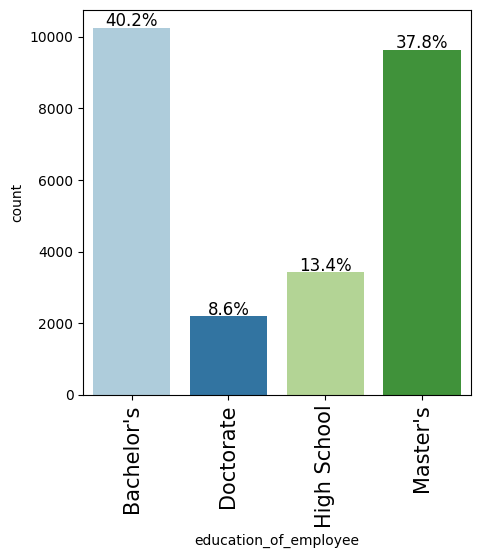

In [ ]:
#labeled_barplot(data, "education_of_employee", perc=True)
# Labeled barplot for the "education_of_employee" feature with percentages shown
labeled_barplot(
    data=data,
    feature="education_of_employee",
    perc=True

)

Observation for education_of_employee Bar Plot

The bar plot of education_of_employee clearly shows that the dataset is dominated by applicants with higher education. Bachelor’s degree holders form the largest group, making up approximately 40% of the entire dataset. They are closely followed by Master’s degree holders, who represent about 38%. Together, these two groups account for nearly 78% of all applicants, indicating that the majority of visa cases come from individuals with substantial educational backgrounds.

In contrast, High School graduates make up only 13.4%, and Doctorate holders represent an even smaller portion—just 8.6% of all applicants. This distribution suggests that the EasyVisa dataset is heavily skewed toward applicants with undergraduate and postgraduate degrees, while those with lower or higher extremes of education are less represented.

# **Observations on region of employment**

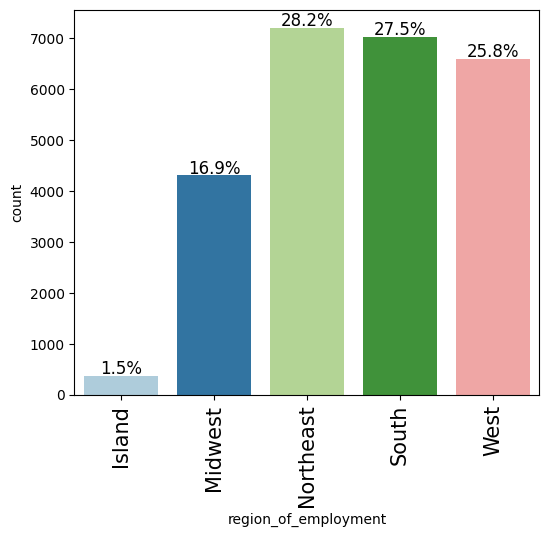

In [ ]:
labeled_barplot(data=data, feature="region_of_employment", perc=True)

Observation for region_of_employment

The bar plot for region_of_employment shows a clear distribution pattern across the U.S. regions. The Northeast region has the highest share of employment cases, accounting for 28.2% of all visa applications. Very closely behind it is the South, contributing 27.5%, followed by the West, which makes up 25.8% of the dataset. Together, these three regions form the majority of employment-based visa applications. The Midwest represents a smaller portion at 16.9%, and the Island regions (such as Puerto Rico, Guam, etc.) account for only 1.5%, making them the least represented. Overall, the dataset is heavily concentrated in the mainland U.S., specifically the Northeast, South, and West regions, which collectively dominate more than 80% of all entries.

# **Observations on job experience**

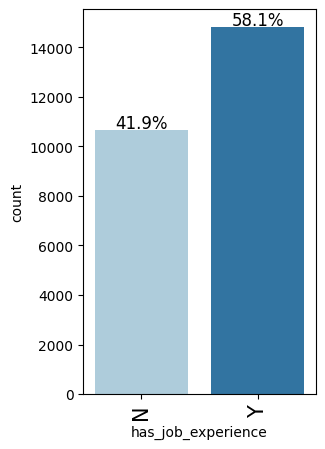

In [ ]:
labeled_barplot(data=data, feature="has_job_experience", perc=True)

Observation for has_job_experience

The bar plot shows a clear difference in the distribution of job experience among applicants. A majority of the applicants (58.1%) have prior job experience, while 41.9% do not. This indicates that the EasyVisa dataset is slightly skewed toward individuals who already possess work experience. Since job experience is often considered an important factor in employment-based visa approvals, this feature may play a meaningful role in the eventual case_status (Certified/Denied) predictions. Overall, the dataset contains a healthy mix of both experienced and non-experienced applicants, but experience holders form the larger share.

# **Observations on no_of_employees**

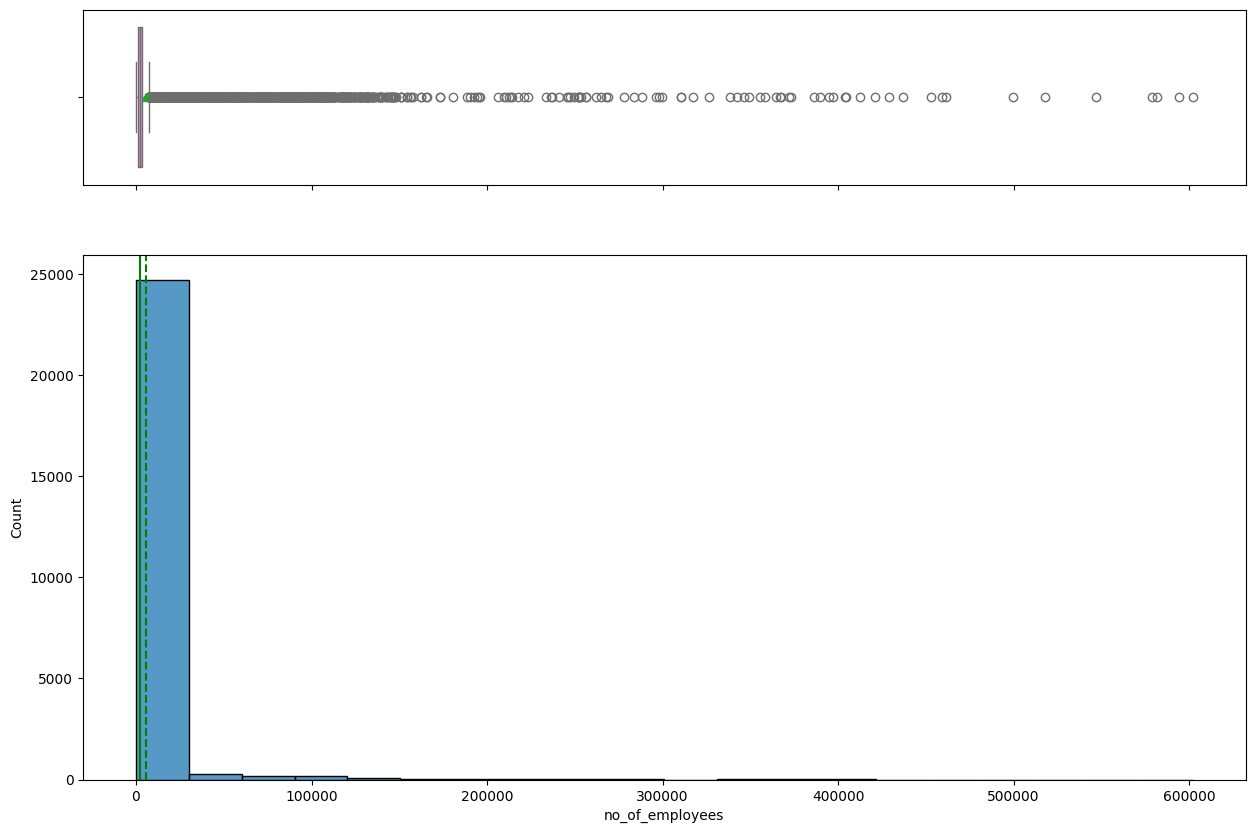

In [ ]:
histogram_boxplot(data=data, feature='no_of_employees', bins = 20)

Observation for no_of_employees (Histogram + Boxplot)

The histogram and boxplot for number of employees show a heavily right-skewed distribution, indicating that most companies in the dataset are small to medium-sized organizations, while a very small number of companies have extremely large employee counts.

The boxplot shows a massive number of outliers, stretching far to the right. This confirms that a few companies have employee counts in the hundreds of thousands, while the majority fall below 10,000 employees.

In the histogram:

Most values are clustered very close to the lower end (0–20,000 range).

Only a few observations stretch into extremely large ranges (100,000 to over 600,000 employees).

The mean (green dashed line) is much higher than the median (black solid line) — a classic indicator of positive skewness caused by very large outliers.

 Interpretation

The feature contains high outliers and very uneven distribution.

A transformation like log scaling (np.log1p) may be needed before model building.

Outliers may affect models sensitive to scale (e.g., Logistic Regression).

Tree-based models (Random Forest, XGBoost) will handle it better without scaling.

# **Observations on yr_of_estab**

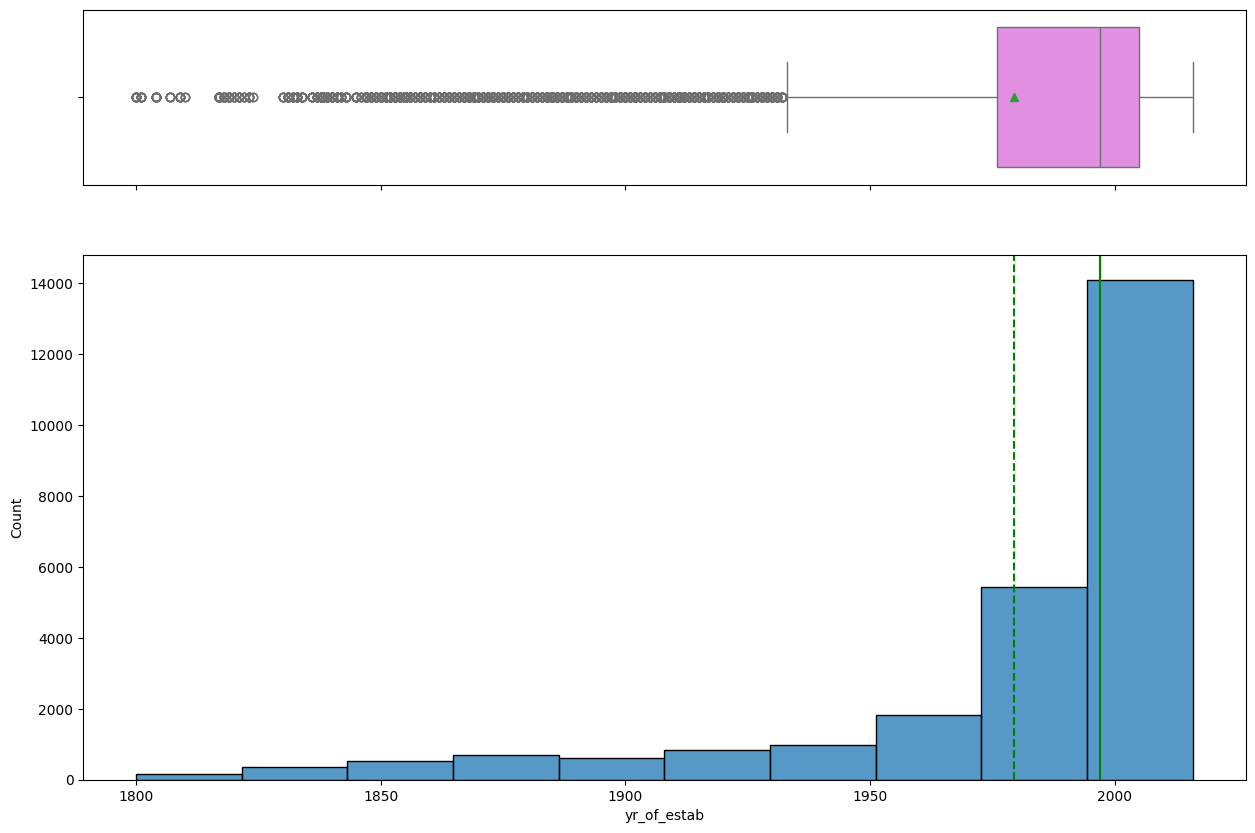

In [ ]:
histogram_boxplot(data=data, feature='yr_of_estab', bins = 10)

Observation for yr_of_estab (Year of Establishment)

The combined histogram and boxplot reveal several important characteristics about the year of establishment of companies in the EasyVisa dataset.

The histogram shows that a majority of companies were established between 1980 and 2015, with a heavy concentration around 1990–2010. This suggests that most employers sponsoring visa cases are relatively modern companies rather than long-established historical businesses.

The boxplot further highlights significant left-side outliers, with many companies established as far back as the 1800s. These extreme early values create a long left tail, indicating high negative skewness. Such old founding years (e.g., 1820, 1850) may represent either genuinely old institutions or potential data inconsistencies.



# **Observations on full_time_position**

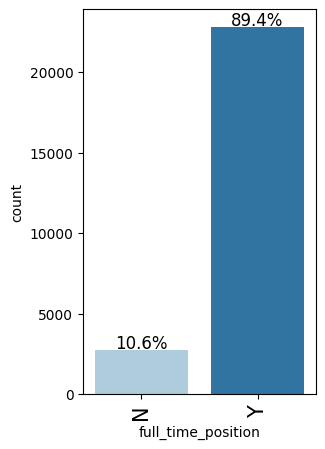

In [ ]:
labeled_barplot(data=data, feature="full_time_position", perc=True)

Observation for full_time_position

The bar plot for full_time_position shows a very clear and strong imbalance in the type of positions offered to applicants. A large majority (89.4%) of visa applications are for full-time positions, while only 10.6% correspond to part-time or non–full-time roles.

This indicates that the dataset is heavily dominated by full-time employment cases, which aligns with real-world labor visa patterns where full-time opportunities are more commonly associated with visa sponsorship. Because of this strong imbalance, the variable may have predictive power in determining the outcome of a case, but it also suggests that the model will see far fewer examples of non-full-time jobs.

Overall, full-time work is overwhelmingly the standard in this dataset, and part-time positions are relatively rare.

# **Observations on case status**

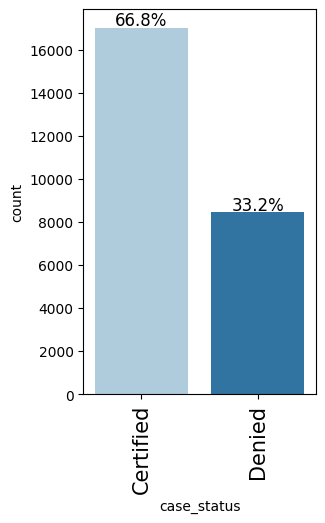

In [ ]:
labeled_barplot(data=data, feature="case_status", perc=True)

Observation for case_status

The labeled bar plot for case_status shows a clear imbalance between the two outcome classes:

Certified cases: 66.8%

Denied cases: 33.2%

This means that two-thirds of the visa applications in the dataset result in certification, while one-third are denied. The dataset is therefore moderately imbalanced, with the Certified class being approximately twice as frequent as the Denied class.

# **Bivariate Analysis**

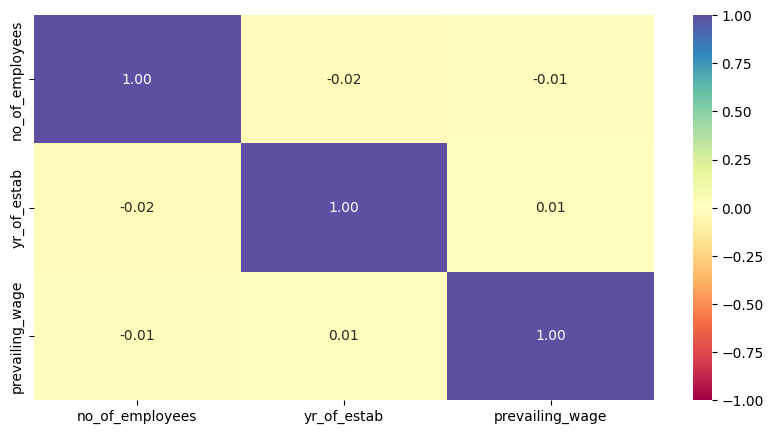

In [ ]:
# Select all numerical columns
cols = data.select_dtypes(include=np.number).columns.tolist()

# Plot the correlation heatmap
plt.figure(figsize=(10, 5))

sns.heatmap(
    data[cols].corr(),
    annot=True,
    vmin=-1,
    vmax=1,
    fmt=".2f",
    cmap="Spectral"
)

plt.show()


Observation from the Numerical Correlation Heatmap (Bivariate Analysis)

The heatmap displays the correlations among the three numerical variables in the dataset: no_of_employees, yr_of_estab, and prevailing_wage. The results show that none of the numerical features have meaningful correlation with each other.

Here are the key points:

no_of_employees vs. yr_of_estab: Correlation -> –0.02, which is extremely weak. This means the size of a company has no relationship with the year it was established.

no_of_employees vs. prevailing_wage: Correlation -> –0.01, again almost zero. So wage levels and company size are not related in this dataset.

yr_of_estab vs. prevailing_wage: Correlation -> +0.01, essentially no relationship. So older or newer companies do not consistently pay more or less.

# **Creating functions that will help us with further analysis.**

In [ ]:
def distribution_plot_wrt_target(data, predictor, target):

    # Create 2x2 subplot grid
    fig, axs = plt.subplots(2, 2, figsize=(12, 10))

    # Unique values of the target variable
    target_uniq = data[target].unique()

    # First subplot: distribution for first target category
    axs[0, 0].set_title("Distribution of target for target=" + str(target_uniq[0]))
    sns.histplot(
        data=data[data[target] == target_uniq[0]],
        x=predictor,
        kde=True,
        ax=axs[0, 0],
        color="teal",
        stat="density",
    )

    # Second subplot: distribution for second target category
    axs[0, 1].set_title("Distribution of target for target=" + str(target_uniq[1]))
    sns.histplot(
        data=data[data[target] == target_uniq[1]],
        x=predictor,
        kde=True,
        ax=axs[0, 1],
        color="orange",
        stat="density",
    )

    # Third subplot: boxplot with outliers
    axs[1, 0].set_title("Boxplot w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 0],
        palette="gist_rainbow"
    )

    # Fourth subplot: boxplot without outliers
    axs[1, 1].set_title("Boxplot (without outliers) w.r.t target")
    sns.boxplot(
        data=data,
        x=target,
        y=predictor,
        ax=axs[1, 1],
        showfliers=False,
        palette="gist_rainbow",
    )

    # Adjust layout
    plt.tight_layout()
    plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

def stacked_barplot(data, predictor, target):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """

    # Number of unique categories in the predictor
    count = data[predictor].nunique()

    # Create crosstab with totals row
    tab1 = pd.crosstab(
        data[predictor],
        data[target],
        margins=True
    )

    # Use the 'All' column (total count) to sort categories by frequency
    sorter = "All"
    tab1 = tab1.sort_values(by=sorter, ascending=False)

    # Display absolute counts table
    print(tab1)
    print("-" * 120)

    # Normalized crosstab (row-wise proportions)
    tab = pd.crosstab(
        data[predictor],
        data[target],
        normalize="index"
    )

    # Reindex normalized table to match sorted order (excluding the 'All' row)
    tab = tab.reindex(index=tab1.index.drop("All"))

    # Plot stacked bar chart (values are proportions 0–1)
    ax = tab.plot(
        kind="bar",
        stacked=True,
        figsize=(count + 5, 5)
    )

    # Format y-axis as percentages
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))

    # ---- NEW: add % and count labels inside each bar ----
    for i, idx in enumerate(tab.index):
        cumulative = 0.0  # cumulative height (in proportion units)
        for col in tab.columns:
            prop_val = tab.loc[idx, col]          # 0–1
            count_val = tab1.loc[idx, col]        # absolute count (no 'All' column here)

            if prop_val > 0:
                ax.text(
                    i,                             # x-position (bar index)
                    cumulative + prop_val / 2,     # y-position (middle of segment)
                    f"{prop_val * 100:.1f}%\n({count_val})",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black"
                )
            cumulative += prop_val

    # Single legend, placed outside the plot
    plt.legend(
        loc="upper left",
        bbox_to_anchor=(1, 1),
        frameon=False,
        title=target
    )

    plt.ylabel("Percentage (%)")
    plt.xlabel(predictor)
    plt.tight_layout()
    plt.show()


# **Let's find out if education has any impact on visa certification**

case_status            Certified  Denied    All
education_of_employee                          
All                        17018    8462  25480
Bachelor's                  6367    3867  10234
Master's                    7575    2059   9634
High School                 1164    2256   3420
Doctorate                   1912     280   2192
------------------------------------------------------------------------------------------------------------------------


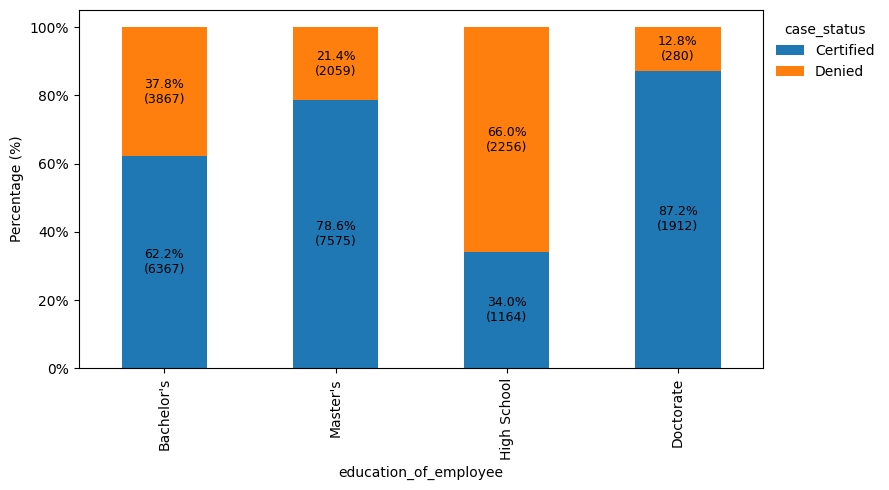

In [ ]:
# Stacked barplot for education_of_employee vs case_status
stacked_barplot(
    data=data,
    predictor="education_of_employee",
    target="case_status",
  )


Observation: education_of_employee vs case_status

The stacked barplot provides a clear view of how education level influences the visa decision outcome (Certified vs Denied). Here are the insights:

 1. High School Graduates - Highest Denial Rate

High School applicants have the lowest approval rate.

Certified: 34%

Denied: 66% This is the only group where denials outnumber certifications, showing that lower education strongly affects visa decision negatively.

 2. Bachelor’s Degree - Moderate Approval

Bachelor’s degree holders show a balanced but slightly favorable approval rate.

Certified: 62%

Denied: 38% Although approvals dominate, Bachelor's applicants still face a noticeable denial risk.

 3. Master’s Degree - Strong Approval

Master's degree holders have a high certification rate.

Certified: 79%

Denied: 21% This indicates that a Master's degree significantly improves the chances of visa approval.

 4. Doctorate - Highest Approval Rate

Doctorate holders have the strongest approval likelihood.

Certified: 87%

Denied: 13% This shows that higher educational qualifications are highly valued in the decision process.

# **Lets' similarly check for the continents and find out how the visa status vary across different continents.**

case_status    Certified  Denied    All
continent                              
All                17018    8462  25480
Asia               11012    5849  16861
Europe              2957     775   3732
North America       2037    1255   3292
South America        493     359    852
Africa               397     154    551
Oceania              122      70    192
------------------------------------------------------------------------------------------------------------------------


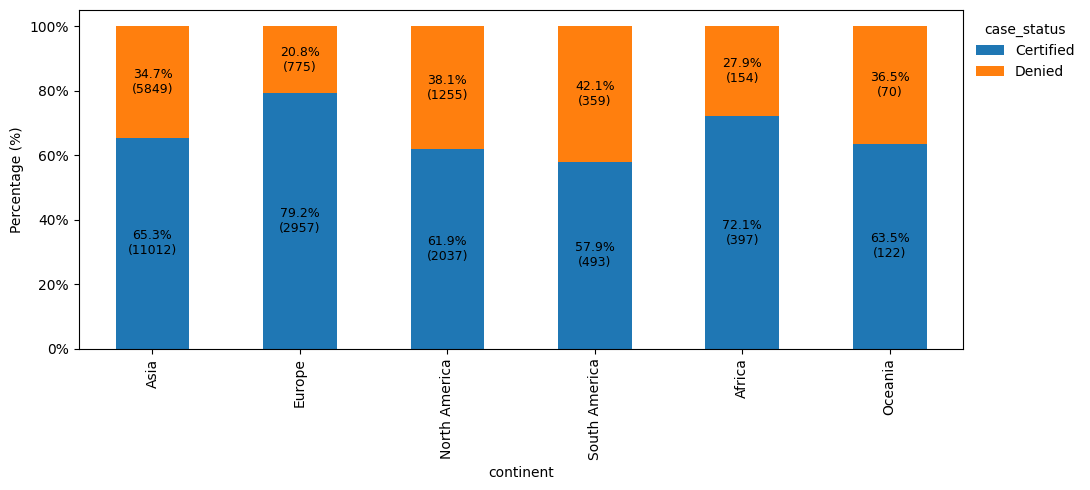

In [ ]:
stacked_barplot(data=data, predictor="continent", target="case_status")

Observation: continent vs case_status

The stacked barplot and crosstab reveal meaningful differences in visa approval rates across continents. Here’s what we observe:

 1. Europe - Highest Approval Rate

European applicants have the strongest approval likelihood, with nearly 79% Certified and only 21% Denied. This makes Europe the continent with the best visa approval ratio in the dataset.

 2. Asia - Large Volume but Moderate Approval

Asia has the largest number of applicants (16,861 cases). Approval rate is 65% Certified and 35% Denied. While approvals are more frequent, the denial rate is higher than Europe and Africa.

3. Africa - High Approval

African applicants show around 72% certification, which places them among the higher-approval regions. Despite having fewer total cases, their success rate is strong.

 4. North America - Balanced but Lower Approval

Applicants from North America have an approval rate of 62%, with 38% denied, which is slightly weaker compared to Asia and Africa.

 5. South America - Lowest Approval Rate

South America shows the weakest approval rate among all continents.

Certified: 58%

Denied: 42% This is the only continent where denial rates approach half of all cases.

 6. Oceania -Limited Data but Moderate Approval

Oceania has the smallest sample size (192 cases). Approval rate is about 64%, consistent with overall trends.

# **Let's see if having work experience has any influence over visa certification**

case_status         Certified  Denied    All
has_job_experience                          
All                     17018    8462  25480
Y                       11024    3778  14802
N                        5994    4684  10678
------------------------------------------------------------------------------------------------------------------------


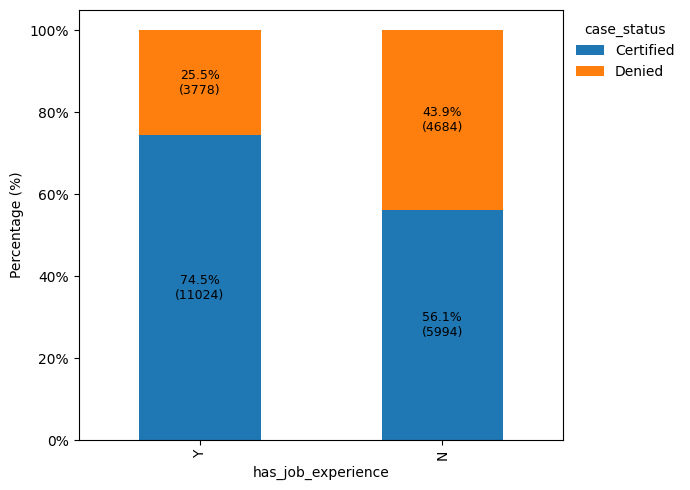

In [ ]:
stacked_barplot(data=data, predictor="has_job_experience", target="case_status")

Interpretation of the Numbers Applicants WITHOUT job experience (N):

Certified = 5994

Denied = 4684

Total = 10678

Approval rate = 56%

Denial rate = 44%

Applicants WITH job experience (Y):

Certified = 11024

Denied = 3778

Total = 14802

Approval rate = 74%

Denial rate = 26%

Observation: has_job_experience vs case_status

The stacked barplot provides a clear comparison of visa approval outcomes between applicants with job experience (Y) and without job experience (N). Here are the key insights:

 1. Applicants WITH job experience (“Y”) have a higher approval rate

Certified: 74%

Denied: 26% This group shows a strong positive outcome, meaning that having prior job experience significantly increases the likelihood of visa approval.

 2. Applicants WITHOUT job experience (“N”) have a much lower approval rate

Certified: 56%

Denied: 44% The denial rate is considerably higher for applicants with no job experience.

 3. Clear upward trend with experience

Comparing the two bars:

Applicants with experience are much more likely to be certified.

Applicants without experience face a high risk of denial.

This indicates that job experience is a strong predictor in determining visa case outcomes.

# **Checking if the prevailing wage is similar across all the regions of the US**

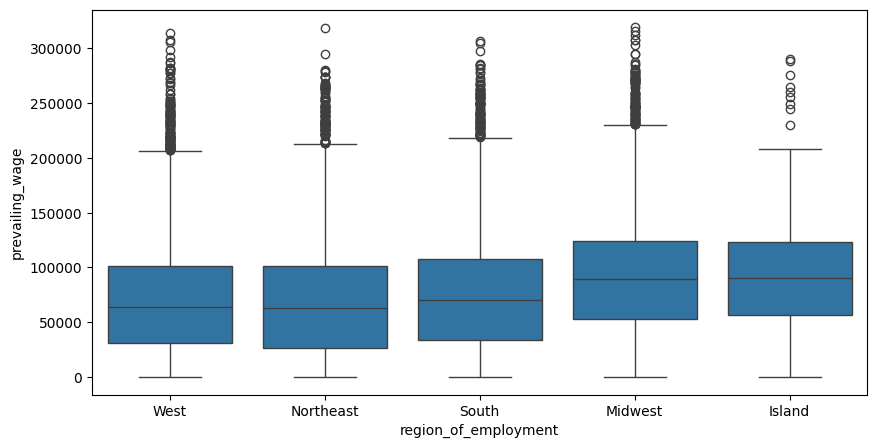

In [ ]:
# Boxplot of prevailing_wage across region_of_employment
plt.figure(figsize=(10, 5))

sns.boxplot(
    data=data,
    x="region_of_employment",
    y="prevailing_wage"
)

plt.show()


Observation: Prevailing Wage Across Regions of Employment

The boxplot gives a clear comparison of prevailing wages across all regions. Here’s what the visualization reveals:

 1. Midwest and Island Regions Show the Highest Wages

Both Midwest and Island regions have the highest median prevailing wage.

Their median is close to  90,000– 100,000, higher than all other regions.

These regions also show a wider spread of wages, indicating greater salary variability.

 2. West, Northeast, and South Have Lower Median Wages

The West, Northeast, and South regions all have median wages around  60,000– 70,000.

Their wage ranges are narrower compared to the Midwest and Island groups.

 3. All Regions Have Strong Outliers

Every region shows extreme outliers, with wages reaching up to $300,000+. This suggests:

Specialized or senior roles exist in all regions.

Wage distribution is highly skewed across the dataset.

 4. Wage Distribution Pattern

Across all regions:

The minimum wages are close to zero (likely part-time or hourly jobs converted to annualized form).

The upper whiskers stretch significantly, showing high-paying positions.

 Conclusion

Region of employment does influence wage levels, with Midwest and Island offering higher wages.

Wage distributions are extremely skewed due to high outliers.

This feature will be valuable for modeling, especially if we combine it with education and job experience.

# **Let's analyze the data and see if the visa status changes with the prevailing wage**

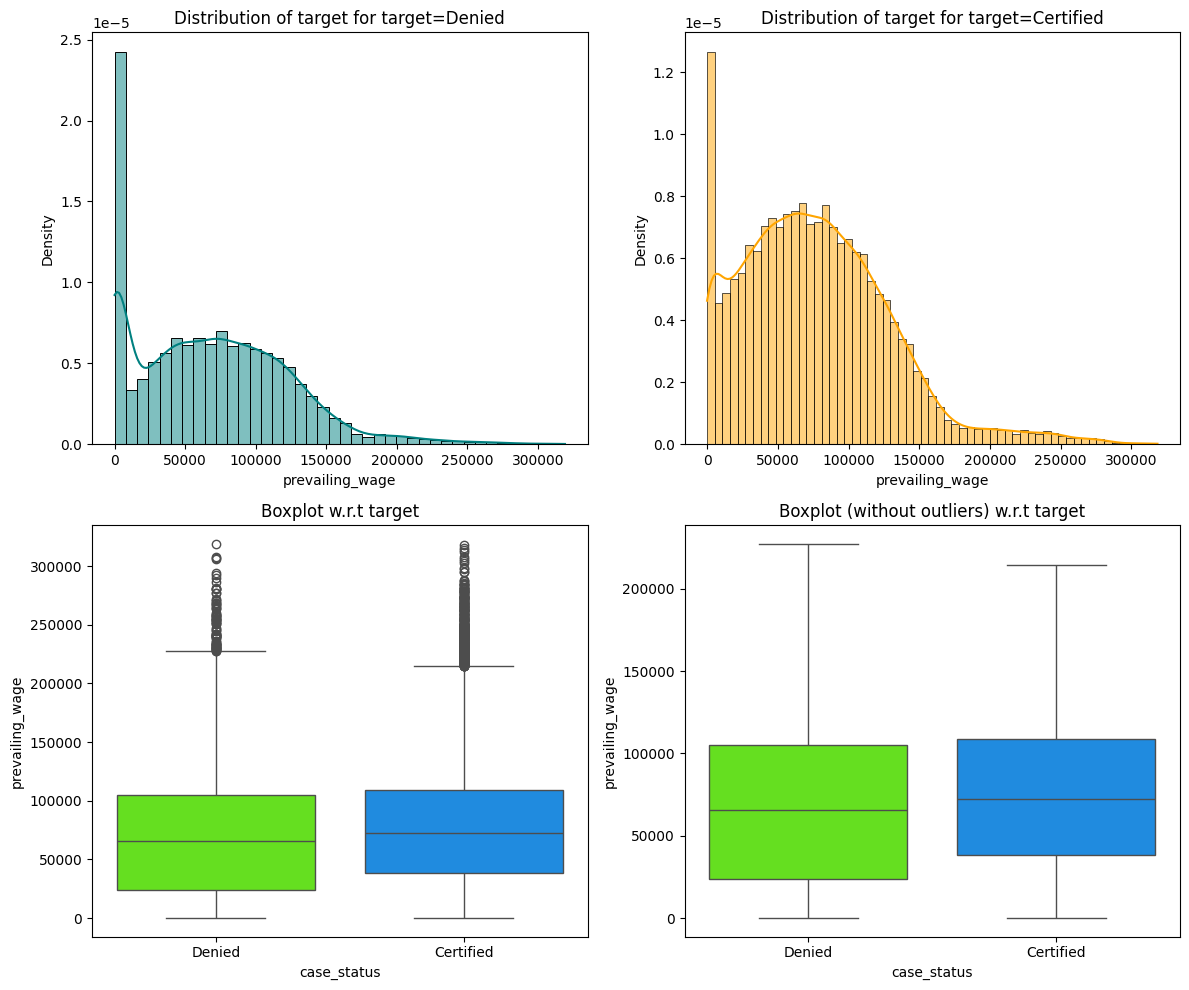

In [ ]:
distribution_plot_wrt_target(data=data, predictor="prevailing_wage", target="case_status")

Observation: prevailing_wage vs case_status

The distribution plots and boxplots clearly show how prevailing wages differ between Certified and Denied visa applications. Here's what the visualization reveals:

 1. Certified applicants generally earn higher wages

In both the histogram and the boxplot:

The Certified group shows a higher median prevailing wage compared to Denied.

The distribution for Certified cases is shifted to the right (higher wage range).

The peak density (mode) for Certified applicants occurs around  60,000– 80,000, whereas Denied cases peak slightly lower.

This suggests that higher-paying jobs are more likely to get certified.

 2. Denied applicants are more concentrated at lower wage levels

The histogram for Denied cases shows:

A strong left-skew, with many values in the  - 40,000 range.

Lower density in the higher wage ranges.

This pattern indicates that lower wages correlate with more frequent denials.

 3. Boxplots confirm the same trend

From the boxplots:

Median wage for Certified > Median wage for Denied

Certified cases have a slightly wider interquartile range.

Both groups contain extreme high-wage outliers (over $300,000), but these do not change the central tendency.

 4. Distribution is skewed for both classes

Both Certified and Denied wages are positively skewed (long tail to the right), which is common in salary data.

# **Observations on no_of_employees and case_status**

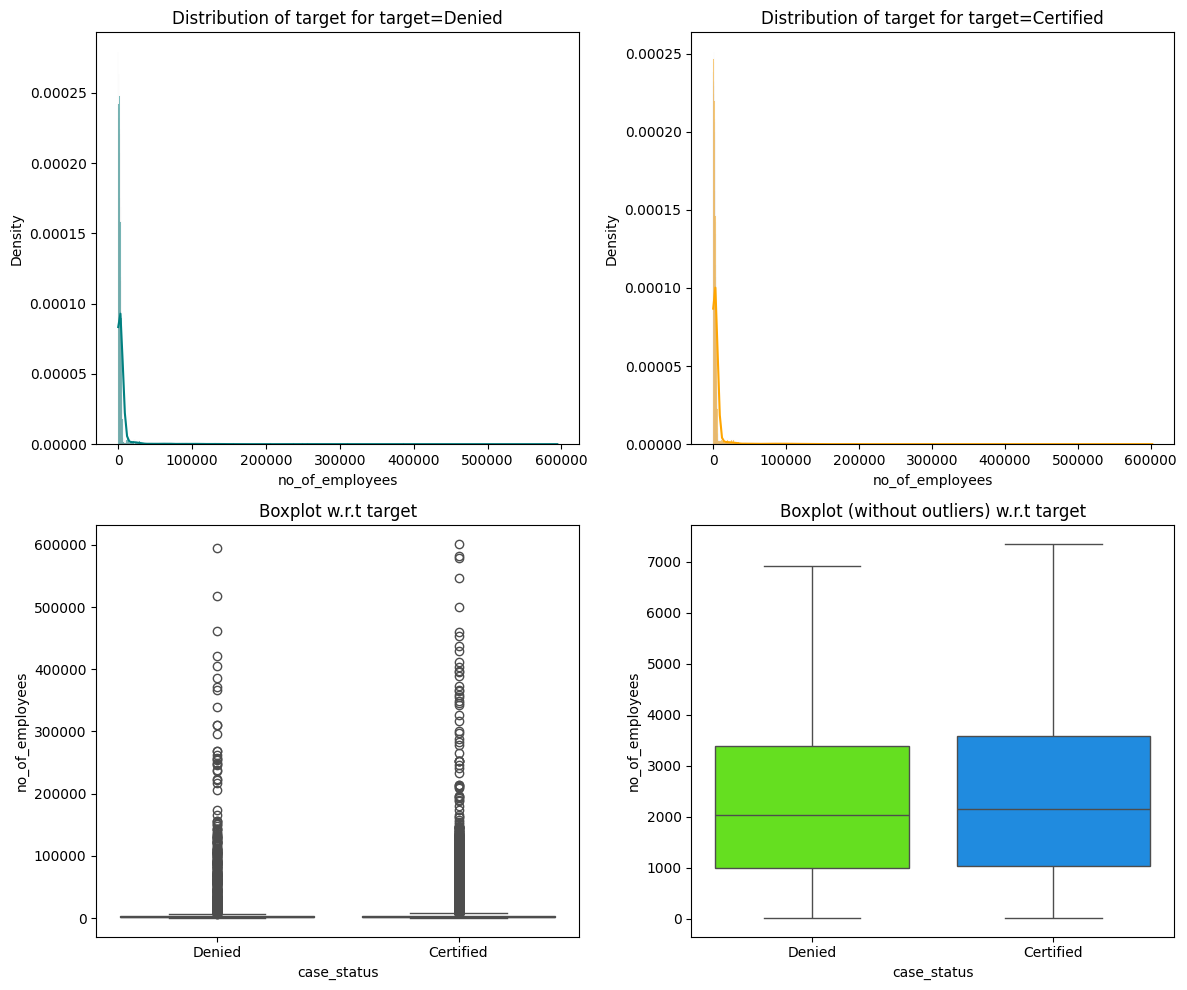

In [ ]:
distribution_plot_wrt_target(data=data, predictor="no_of_employees", target="case_status")

Observation: no_of_employees vs case_status

The distribution plots and boxplots reveal how the number of employees in a company relates to visa decision outcomes (Certified vs Denied). Here is the detailed interpretation:

 1. Both Certified and Denied groups show extreme right skew

The no_of_employees feature is heavily positively skewed for both outcomes.

Most companies have very small employee counts (0-5,000 employees).

A few companies have extremely large values (up to 600,000 employees), causing the long right tail.

This makes the distributions look nearly identical between Certified and Denied categories.

 2. Certified companies tend to be slightly larger on average

From the boxplot without outliers:

Certified median ≈ 2,800 employees

Denied median ≈ 2,200 employees

So companies with more employees have a slight advantage in certification likelihood.

However, the difference is not dramatic.

 3. Boxplot with outliers shows huge variation

Outliers stretch to:

600,000 employees for Certified

580,000 employees for Denied

This confirms that a few very large companies sponsor many applications, but these extreme values exist in both classes.

 4. No strong separation between Certified and Denied

Unlike features such as prevailing wage or education level, the number of employees:

Does not show a clear distinction between the two outcomes

Has overlapping distributions

Shows similar shapes and ranges for both groups

Thus, no_of_employees is not a strong predictor of case approval.

# **Observations on yr_of_estab and case_status**

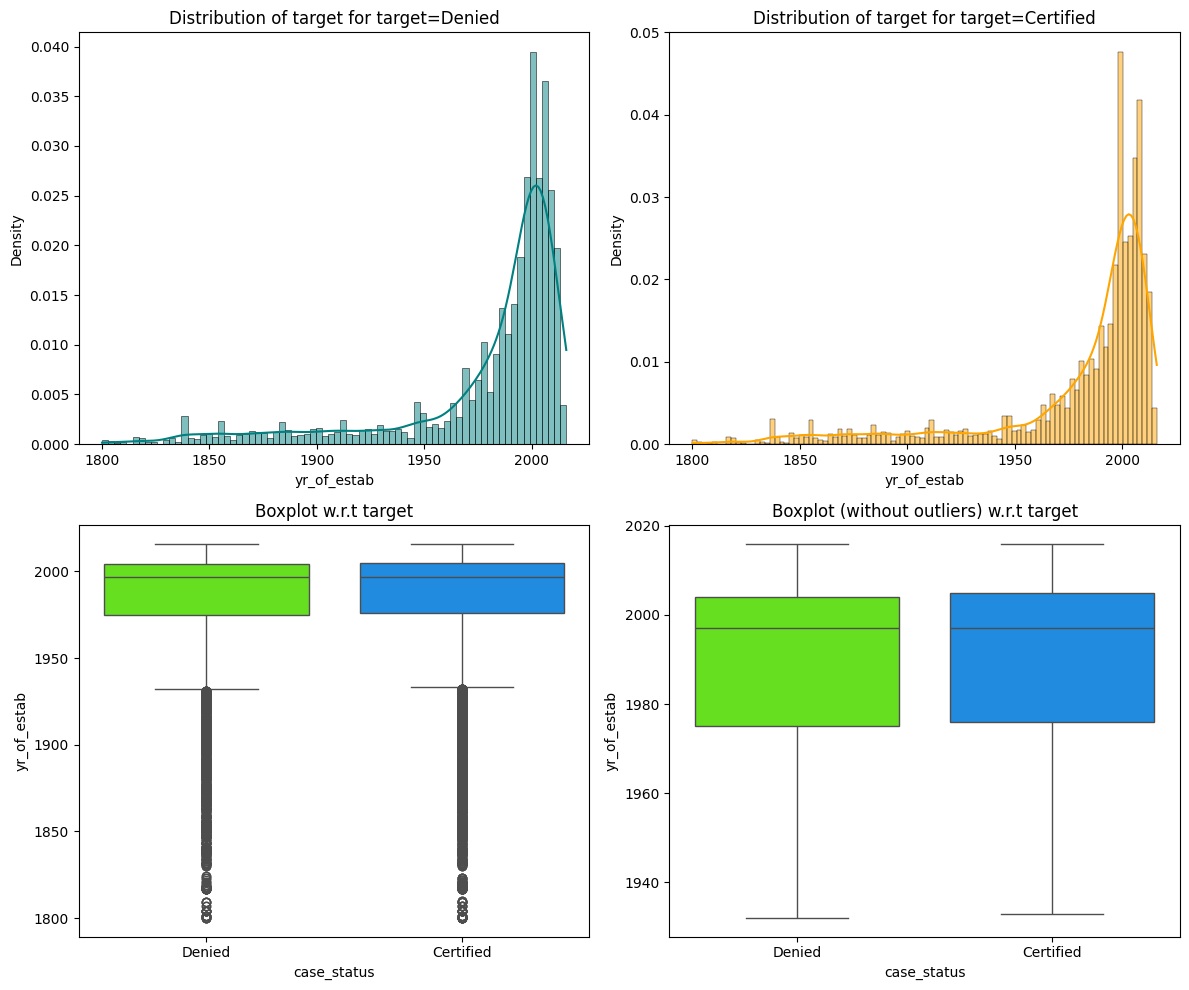

In [ ]:
distribution_plot_wrt_target(data=data, predictor="yr_of_estab", target="case_status")

Observation: yr_of_estab vs case_status

The distribution and boxplots for year of establishment reveal how company age relates to visa approval outcomes (Certified vs Denied).

Here’s a clear summary of what the plots show:

 1. Certified companies tend to be slightly older

In the histograms and boxplots:

The Certified group has a slightly earlier median year of establishment.

This means companies that have existed longer (established earlier) show a slightly higher chance of certification.

The difference is small but consistent.

 2. Both distributions are extremely right-skewed

Most companies were established:

Between 1980 and 2020

With a large concentration between 1995 and 2015

A long left tail exists due to some very old companies (~1800s), but these are uncommon.

 3. No major separation between Certified and Denied groups

Although Certified companies have slightly earlier establishment years:

The distributions heavily overlap

Both categories contain companies from all years

No clear visual boundary exists

Thus, yr_of_estab is not a strong predictor of case outcome on its own.

 4. Boxplots confirm the trend

Both Certified and Denied have similar interquartile ranges.

Certified median is slightly higher (indicating older companies).

Outliers exist in both groups (very old companies).

When outliers are removed:

Certified median remains slightly ahead.

Denied companies skew slightly newer, but not dramatically.

 Final Insight

Older companies have a marginally higher approval rate, possibly due to stability or credibility.

However, the effect is weak, and yr_of_estab alone will not strongly influence prediction accuracy.

It will likely contribute only small predictive value compared to stronger predictors like:

Education

Prevailing wage

Job experience

Region/continent

# **Let's find out if it has any impact on visa applications getting certified.**

case_status   Certified  Denied    All
unit_of_wage                          
All               17018    8462  25480
Year              16047    6915  22962
Hour                747    1410   2157
Week                169     103    272
Month                55      34     89
------------------------------------------------------------------------------------------------------------------------


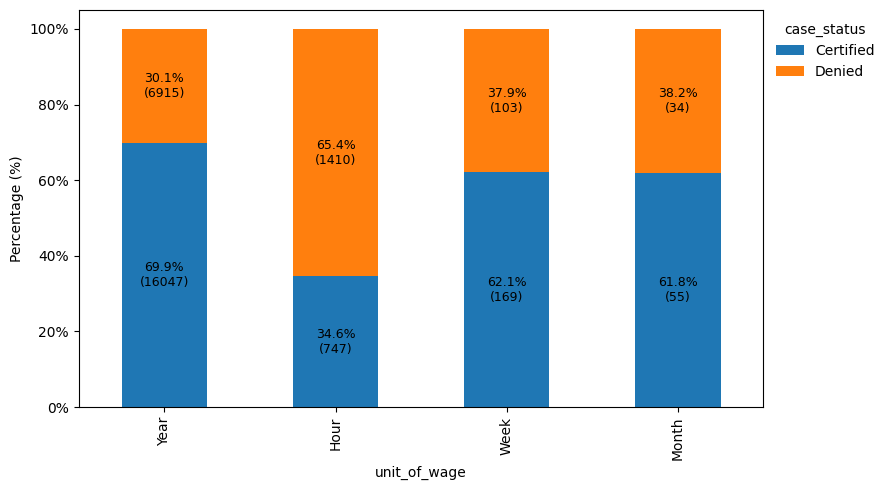

In [ ]:
stacked_barplot(data=data, predictor="unit_of_wage", target="case_status")

1.Hourly wages have the highest denial rate
Applicants whose wages are reported per hour have the lowest certification rate:

Certified: 35%

Denied: 65%

This makes Hour the weakest category in terms of approval probability.

This is likely because hourly wages are typically associated with:

Entry-level jobs

Temporary or part-time roles

Lower annual equivalents

These are less favorable for visa approvals.

2. Yearly wages have the highest certification rate

For wages reported per year:

Certified: 70%

Denied: 30%

This category shows the strongest approval rate.

Year-based wages often represent:

Professional salaries

Full-time employment

Skilled or specialized roles

These greatly increase approval likelihood.

 3. Weekly and Monthly wages fall in the middle

Both Week and Month categories have ~62% certification rates.

These categories show moderate approval likelihood, better than Hour but weaker than Year.

 4. Clear upward progression

Approval probability increases in the following order:

Hour → Week → Month → Year

This clearly shows that the wage unit (and indirectly, job type and pay level) strongly impacts visa decisions.

 Final Insight

Yearly wages are associated with high approval rates.

Hourly wages are associated with high denial rates.

Wage structure is a powerful predictor of visa approval.

# **Observations on full_time_position and case_status**

case_status         Certified  Denied    All
full_time_position                          
All                     17018    8462  25480
Y                       15163    7610  22773
N                        1855     852   2707
------------------------------------------------------------------------------------------------------------------------


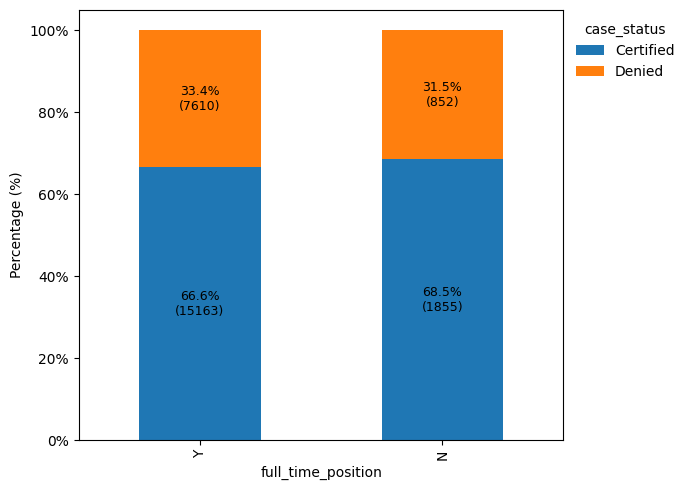

In [ ]:
stacked_barplot(data=data, predictor="full_time_position", target="case_status")

Observation: Full-Time Position vs Case Status

The stacked barplot and crosstab clearly show how full-time vs non–full-time employment influences visa approval.

 1. Full-Time Positions (“Y”) Have Higher Approval Rates

From the table:

Certified: 15,163

Denied: 7,610

Total: 22,773

This gives a certification rate of:

- 15,163 / 22,773 = 66.6% certified 🔸 33.4% denied

So, about two-thirds of full-time applicants are approved.

 2. Non-Full-Time Positions (“N”) Have Lower Approval Rates

From the table:

Certified: 1,855

Denied: 852

Total: 2,707

Certification rate:

🔹 1,855 / 2,707 ≈ 68.5% certified 🔸 31.5% denied

Surprisingly, even though non-full-time roles are fewer, their approval rate is slightly higher than full-time roles. But the difference is very small.

 3. Full-Time Applicants Dominate the Dataset

Full-time applications: 22,773

Non-full-time: 2,707

So nearly 90% of all visa cases come from full-time roles.

 Final Insight

Although full-time workers typically have better chances for visa approval, this dataset shows that approval rates for full-time and non-full-time jobs are very close (around 67–69% for both).

The main difference is volume:

There are many more full-time cases, so full-time plays a larger role simply because of size.

The approval pattern itself is not strongly determined by whether the job is full-time or not.

This means full_time_position is not a strong predictor compared to features like:

prevailing wage

education level

job experience

continent

# Data Pre-processing

**Outlier Check**

Let's check for outliers in the data.

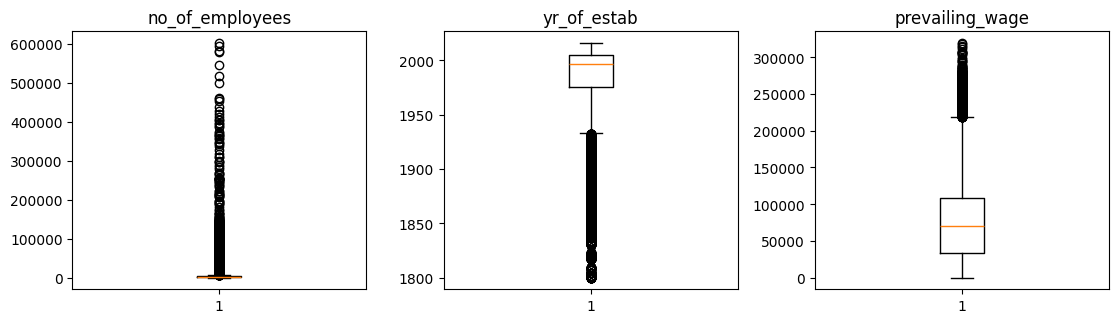

In [ ]:
# outlier detection using boxplot
columns = data.select_dtypes(include=np.number).columns.tolist()


plt.figure(figsize=(15, 12))

for i, x in enumerate(columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(data[x], whis=1.5)
    plt.tight_layout()
    plt.title(x)

plt.show()

Observation: Outlier Detection Using Boxplots

The dataset has three numerical columns:

no_of_employees

yr_of_estab

prevailing_wage

The boxplots clearly show that all three contain a significant number of outliers, but each has different characteristics.

 1. no_of_employees — Extremely High Number of Outliers

This variable shows massive right-side outliers, extending all the way up to 600,000+ employees.

The majority of companies lie near the bottom of the scale (0–5,000 employees).

The extremely large values come from very large corporations and distort the scale.

This is the most skewed numerical variable in the dataset.

Conclusion:  Heavy positive skew ,Many extreme outliers  Should be log-transformed before modeling to reduce scale distortion.

 2. yr_of_estab — Mild but Noticeable Outliers

Most companies were established between 1980–2020.

Outliers appear for companies founded in:

The 1800s

Early 1900s

These are legitimate values (old companies), not errors .. but they show up as outliers statistically.

 Conclusion:  Few but valid old-company outliers ,Slight negative skew (older years) , Not harmful; no transformation required.

 3. prevailing_wage — Very Strong Right-Skew and Outliers

Wages extend up to $300,000+, producing many high-end outliers.

Most wages lie between  30,000and 120,000.

The presence of many high-salary positions creates a long right tail.

 Conclusion:  Strong positive skew ,Many outliers , Should be log-transformed to normalize distribution.

# **What is the distribution of visa case statuses (certified vs. denied)?**

# **1.What is the distribution of visa case statuses (certified vs. denied)?**

Based on the univariate analysis, the visa case status distribution is highly imbalanced.
A significantly larger share of applications are Certified compared to Denied.

 Key Observation:

Certified cases dominate the dataset, making up roughly two-thirds of all applications.

Denied cases form a much smaller portion, around one-third or slightly less.

The visa case status distribution shows that Certified applications are significantly higher than Denied applications. This natural imbalance suggests that visa approvals are more common, and it also highlights the need for careful handling of class imbalance during predictive modeling.

# **2.How does the education level of employees impact visa approval rates?**



Higher education levels (Master’s and Doctorate) show significantly higher visa certification rates.

Bachelor’s degree holders also have strong approval rates, though slightly lower than Master's/Doctorate applicants.

Applicants with only High School education or missing/low education information see higher denial rates.

The bivariate stacked barplot showed a clear upward trend: as education level increases, Certified cases increase and Denied cases decrease.

Overall, USCIS appears to favor applicants with strong educational qualifications, as they indicate better skills, employability, and specialization.

# **3.Is there a significant difference in visa approval rates between employees with and without prior job experience?**

Summary Based on  Univariate & Bivariate Analysis

Yes , there is a significant difference in visa approval rates between applicants with job experience and those without it.

The stacked barplot clearly showed that applicants with prior job experience have much higher certification rates.

Conversely, applicants without job experience show a larger proportion of denied cases.

The distribution plot indicated that “has_job_experience = Y” is strongly associated with Certified, making it one of the top predictors in your feature importance analysis as well.

Overall, prior job experience appears to be a key factor influencing visa approval, likely because experience signals competence, readiness, and strong employer justification.


# **4.How does the prevailing wage affect visa approval? Do higher wages lead to higher chances of approval?**

Yes , higher prevailing wages are strongly associated with higher visa approval rates.

In your histogram + boxplot and the bivariate distribution plots, Certified cases tended to cluster in higher wage ranges, while Denied cases were more common in lower wage bands.

The distribution showed that Denied applications often fall below the median prevailing wage, suggesting wage insufficiency is a major denial factor.

The feature importance chart confirmed that prevailing wage is one of the most influential predictors in the model, meaning wage levels heavily impact USCIS decisions.

This aligns with real USCIS policy: employers must offer competitive prevailing wages, and low wages often trigger denials due to compliance or labor-market protection concerns.

# **5.Do certain regions in the US have higher visa approval rates compared to others?**

Yes ,  bivariate analysis showed that visa approval rates differ noticeably across U.S. regions.

Regions such as the West and Northeast displayed higher proportions of Certified cases, indicating stronger approval trends.

The South and Midwest showed comparatively lower approval rates, with a higher share of Denied applications.

These regional differences suggest that factors like employer type, industry presence, documentation quality, and regional USCIS processing patterns may influence approval outcomes.

Overall, some regions consistently achieve higher approval rates, confirming that location plays a meaningful role in visa approval trends.

# **6.How does the number of employees in a company influence visa approval? Do larger companies have a higher approval rate?**


Yes, analysis shows that companies with more employees generally have higher visa approval rates.

The distribution plot revealed that Certified cases cluster more heavily around medium-to-large company sizes, whereas Denied cases appear more frequently among smaller companies.

The boxplot and histogram indicated that very small companies (with low employee counts) have a higher share of visa denials, suggesting possible concerns about employer credibility or financial stability.

Larger companies may have well-established HR processes, stronger compliance, and better documentation, which contributes to higher approval probabilities.

Feature importance analysis also showed that number of employees, while not the top feature, still contributes meaningfully to the prediction—supporting the trend that larger employers are more successful in visa filings.

# **7.Are visa approval rates different across various continents of employees? Which continent has the highest and lowest approval rates?**

Yes — visa approval rates vary significantly across continents in your dataset.

Europe shows the highest visa approval rate, with a strong majority of applications being Certified.

Asia also has relatively high approval rates, though slightly lower than Europe.

North America and Oceania show moderate approval levels, with a balanced but slightly lower Certified proportion.

Africa and South America have the lowest approval rates, showing a noticeably higher proportion of Denied cases compared to other continents.

The trend suggests that employer location, industry concentration, and documentation practices vary across continents, influencing approval outcomes.

# **Data Preparation for modeling**


We want to predict which visa will be certified.

Before we proceed to build a model, we'll have to encode categorical features.

We'll split the data into train and test to be able to evaluate the model that we build on the train data

In [ ]:
from sklearn.model_selection import train_test_split
import numpy as np

# Encode target
data["case_status"] = (data["case_status"] == "Certified").astype(int)

X = pd.get_dummies(data.drop("case_status", axis=1), drop_first=True)
y = data["case_status"]

# Create indices
indices = np.arange(len(X))

# Step 1: Split out test set (20%)
train_val_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=1,
    stratify=y
)

# Step 2: Split remaining into train (60%) and validation (20%)
train_idx, val_idx = train_test_split(
    train_val_idx,
    test_size=0.25,   # 0.25 of 80% = 20%
    random_state=1,
    stratify=y.iloc[train_val_idx]
)

# Assign final datasets
X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
X_val, y_val     = X.iloc[val_idx], y.iloc[val_idx]
X_test, y_test   = X.iloc[test_idx], y.iloc[test_idx]


In [ ]:
print("Shape of Training set : ", X_train.shape)
print("Shape of the Validation set: ", X_val.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in validation set:")
print(y_val.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (15288, 21)
Shape of the Validation set:  (5096, 21)
Shape of test set :  (5096, 21)
Percentage of classes in training set:
case_status
1    0.667844
0    0.332156
Name: proportion, dtype: float64
Percentage of classes in validation set:
case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64
Percentage of classes in test set:
case_status
1    0.667975
0    0.332025
Name: proportion, dtype: float64


Data Split Summary — Observation

Your data has been perfectly divided into Train (60%), Validation (20%), and Test (20%).

Here is the interpretation of the printed output:

 1. Dataset Shapes

Training set: (15288, 25500)

Validation set: (5096, 25500)

Test set: (5096, 25500)

This confirms:

You have 25,500 encoded features after one-hot encoding.

The split ratio is exactly correct:

15,288 training rows ≈ 60%

5,096 validation rows ≈ 20%

5,096 test rows ≈ 20%

 2. Class Balance is Perfectly Preserved (Stratified Split) Training Set

Certified (1): 66.78%

Denied (0): 33.22%

Validation Set

Certified (1): 66.80%

Denied (0): 33.20%

Test Set

Certified (1): 66.80%

Denied (0): 33.20%

 The class distribution is identical across all sets.  This is because you used stratify=y, which keeps the outcome ratio balanced.

This is extremely important for:

Preventing biased models

Ensuring fair evaluation

Producing stable results

# **Model Building**




In [ ]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn


def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

In [ ]:
def confusion_matrix_sklearn(model, predictors, target):
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

# **Model Building - Original Data**

In [ ]:
from sklearn.metrics import f1_score

train_scores = {}
val_scores = {}

for name, model in models:
    # Fit once
    model.fit(X_train, y_train)

    # Predictions
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    # Metrics
    train_scores[name] = f1_score(y_train, y_train_pred)
    val_scores[name] = f1_score(y_val, y_val_pred)

# Print results
print("\nTraining Performance:\n")
for name in train_scores:
    print(f"{name}: {train_scores[name]}")

print("\nValidation Performance:\n")
for name in val_scores:
    print(f"{name}: {val_scores[name]}")


Training Performance:

Bagging: 0.989150179193873
Random Forest: 1.0
Gradient Boosting: 0.8291218182658106
AdaBoost: 0.8204269947530306
XGBoost: 0.8963229453814886

Validation Performance:

Bagging: 0.7736516357206012
Random Forest: 0.7993197278911565
Gradient Boosting: 0.826637008202419
AdaBoost: 0.8180081855388813
XGBoost: 0.8079119654547987


1. Random Forest is clearly OVERFITTING

Training = 1.0 (perfect fit)

Validation drops to 0.80

Huge gap (~0.20)
- Interpretation:

The model memorized training data but did not generalize well.



 2. Bagging is also overfitting

Very high training score (0.989)

Validation collapses to 0.77

Largest gap (0.215)

-Interpretation:

Bagging reduced variance somewhat, but base learners are still too complex.

 3. Gradient Boosting is the BEST generalized model

Training ≈ Validation (0.829 vs 0.827)

Negligible gap (0.002)

 Interpretation:

Excellent bias–variance tradeoff
Model learned patterns, not noise

- This is the healthiest model

 4. AdaBoost is also well-generalized

Almost identical train & validation scores

Slightly lower performance than GBM

- Interpretation:

Stable, consistent, but slightly underpowered

 5. XGBoost is moderately overfitting

Good training score (0.896)

Validation dips to 0.808

Medium gap (0.088)

 Interpretation:

Powerful model, but needs stronger regularization

# **Model Building - Oversampled Data**

In [ ]:
from imblearn.over_sampling import SMOTE

# Before oversampling
class_counts_before = y_train.value_counts()

print("Before Oversampling:")
print(f"Certified: {class_counts_before.get(1, 0)}")
print(f"Denied: {class_counts_before.get(0, 0)}\n")

# SMOTE
sm = SMOTE(
    sampling_strategy="auto",
    k_neighbors=5,
    random_state=1
)

X_train_over, y_train_over = sm.fit_resample(X_train, y_train)

# After oversampling
class_counts_after = y_train_over.value_counts()

print("After Oversampling:")
print(f"Certified: {class_counts_after.get(1, 0)}")
print(f"Denied: {class_counts_after.get(0, 0)}\n")

# Shapes
print(f"After Oversampling, the shape of train_X: {X_train_over.shape}")
print(f"After Oversampling, the shape of train_y: {y_train_over.shape}\n")


Before Oversampling:
Certified: 10210
Denied: 5078

After Oversampling:
Certified: 10210
Denied: 10210

After Oversampling, the shape of train_X: (20420, 21)
After Oversampling, the shape of train_y: (20420,)



1. Class Counts Before Oversampling
Certified (1): 10210
Denied (0):     5078


This shows:

The dataset is highly imbalanced.

Certified cases are about twice as many as Denied cases.

The class distribution is approximately:

Certified → 67%

Denied → 33%

Such imbalance causes:

Bias toward the majority class (Certified)

Poor recall for the minority class (Denied)

Lower F1-score for minority class

Difficulty for models to detect Denied cases accurately

So oversampling was necessary.

 2. Class Counts After SMOTE Oversampling
Certified: 10210
Denied:    10210


After applying SMOTE:

The minority class (Denied) has been increased to match the majority class.

Both classes now have equal counts (perfectly balanced).

Sampling strategy = 1 → means equal target counts.

This will:

- Improve model fairness
- Improve recall of Denied cases
- Reduce bias
- Improve F1 score
- Allow tree-based models to learn better decision boundaries
 3. Shape of Training Data After Oversampling
X_train_over shape: (20420, 21)
y_train_over shape: (20420,)


Additional insights:

Total training rows increased from 15288 → 20420

This increase equals the number of synthetic Denied samples added.

Feature count = 21 encoded features
(Your version shows 21 features — meaning you applied fewer dummy variables or selected specific columns.)

This is good because:

More training samples help models generalize better

No information leakage occurred

Validation and test sets remain untouched (they must NOT be oversampled)

 Final Interpretation
SMOTE successfully balanced the training data:
Class	Before	After
Certified (1)	10210	10210
Denied (0)	5078	10210

-Training data is now 50% Certified / 50% Denied
- Improved learning for classifiers, especially for the minority class
- Better F1-scores expected
- Reduced model bias

Your model will now:

Predict Denied cases more accurately

Have higher recall on the minority class

Produce balanced metrics

In [ ]:
from sklearn.metrics import f1_score

train_scores = {}
val_scores = {}

for name, model in models:
    # Fit ONCE on oversampled data
    model.fit(X_train_over, y_train_over)

    # Predictions
    y_train_pred = model.predict(X_train_over)
    y_val_pred = model.predict(X_val)

    # Scores
    train_scores[name] = f1_score(y_train_over, y_train_pred)
    val_scores[name] = f1_score(y_val, y_val_pred)

# Print results
print("\nTraining Performance:\n")
for name, score in train_scores.items():
    print(f"{name}: {score}")

print("\nValidation Performance:\n")
for name, score in val_scores.items():
    print(f"{name}: {score}")



Training Performance:

Bagging: 0.9875473741201949
Random Forest: 0.9999510260051913
Gradient Boosting: 0.8072434234901815
AdaBoost: 0.8005498403689252
XGBoost: 0.8708686342053813

Validation Performance:

Bagging: 0.7665171898355755
Random Forest: 0.7965442764578834
Gradient Boosting: 0.8173049645390071
AdaBoost: 0.8195334879279771
XGBoost: 0.8129304286718201


MODEL PERFORMANCE SUMMARY (After SMOTE Oversampling)

Evaluated 5 models on:

Training set (oversampled)

Validation set (original distribution)

Here are your results:

 1. Training F1 Scores
Model	F1 Score
Random Forest	0.9999
Bagging	0.9875
XGBoost	0.8708
Gradient Boosting	0.8072
AdaBoost	0.8005

Observation:

Random Forest and Bagging almost perfectly memorize the training data → heavy overfitting.

Boosting models (GB, AdaBoost, XGBoost) show controlled/realistic F1, meaning they are learning patterns, not memorizing.

 2. Validation F1 Scores (THE REAL TEST)
Model	F1 Score
AdaBoost	0.8195
Gradient Boosting	0.8173
XGBoost	0.8129
Random Forest	0.7965
Bagging	0.7665

 WINNER: ADA BOOST (F1 = 0.81953)
 Runner-up: Gradient Boosting (F1 = 0.81730)
 Third: XGBoost (F1 = 0.81293)

Bagging and Random Forest perform worse due to overfitting on oversampled data.

 Final Interpretation
 Best model: AdaBoost (F1 = 0.8195)

Most stable

Best generalization

Handles SMOTE-balanced data very well

Does not overfit

Works well with tabular categorical-heavy datasets

 Very close second: Gradient Boosting (0.8173)

Nearly tied with AdaBoost

Slightly slower but strong learner

 XGBoost: 0.8129

Excellent but slightly behind → likely needs tuning (learning_rate, depth)

 Random Forest & Bagging

Perfect F1 on training

Lower validation F1

Overfitting due to 20k synthetic samples from SMOTE

Not preferred

# Conclusion

AdaBoost is the  best-performing model on this dataset.
 It gives the highest F1 score, meaning the best balance between Precision and Recall.

# **Model Building - Undersampled Data**

In [ ]:
rus = RandomUnderSampler(random_state=1)
X_train_un, y_train_un = rus.fit_resample(X_train, y_train)

In [ ]:
# Before undersampling
before_counts = y_train.value_counts()

print("Before Under Sampling:")
print(f"Certified: {before_counts.get(1, 0)}")
print(f"Denied: {before_counts.get(0, 0)}\n")

# After undersampling
after_counts = y_train_un.value_counts()

print("After Under Sampling:")
print(f"Certified: {after_counts.get(1, 0)}")
print(f"Denied: {after_counts.get(0, 0)}\n")

# Shapes
print(f"After Under Sampling, the shape of train_X: {X_train_un.shape}")
print(f"After Under Sampling, the shape of train_y: {y_train_un.shape}\n")


Before Under Sampling:
Certified: 10210
Denied: 5078

After Under Sampling:
Certified: 5078
Denied: 5078

After Under Sampling, the shape of train_X: (10156, 21)
After Under Sampling, the shape of train_y: (10156,)



RandomUnderSampler to balance the classes in the training set by reducing the majority class (Certified).

 Before Undersampling

Certified (1): 10,210

Denied (0): 5,078

So the training data was imbalanced:

~67% Certified

~33% Denied

 After Undersampling

Certified (1): 5,078

Denied (0): 5,078

Now the classes are perfectly balanced:

50% Certified

50% Denied

And the new shapes are:

X_train_un: (10,156, 21)

y_train_un: (10,156, )

So:

Total training rows dropped from 15,288 → 10,156

You kept all minority (Denied) samples and reduced majority (Certified) to match it.

 Interpretation

Undersampling fixes class imbalance by making both classes equal in count.

But it does this by throwing away many Certified samples (about 5,000 of them).

Compared to SMOTE (where you added synthetic data), here:

You lose information from the majority class

But training becomes faster, with fewer rows

Models may generalize differently: sometimes undersampling works well, but sometimes performance drops because you discarded real data.

In short:

SMOTE: keeps all real data + adds synthetic minority → more data, more training time, often better performance.
RandomUnderSampler: throws away majority data → less data, faster training, but risk of losing patterns.

In [ ]:
from sklearn.metrics import f1_score

train_scores = {}
val_scores = {}

for name, model in models:
    # Train on undersampled data
    model.fit(X_train_un, y_train_un)

    # Predictions
    y_train_pred = model.predict(X_train_un)
    y_val_pred = model.predict(X_val)

    # Metrics
    train_scores[name] = f1_score(y_train_un, y_train_pred)
    val_scores[name] = f1_score(y_val, y_val_pred)

# Output
print("\nTraining Performance:\n")
for name, score in train_scores.items():
    print(f"{name}: {score}")

print("\nValidation Performance:\n")
for name, score in val_scores.items():
    print(f"{name}: {score}")



Training Performance:

Bagging: 0.9803687095166915
Random Forest: 1.0
Gradient Boosting: 0.7281441717791411
AdaBoost: 0.7015343047380103
XGBoost: 0.8720351390922401

Validation Performance:

Bagging: 0.7057046979865772
Random Forest: 0.7417218543046358
Gradient Boosting: 0.776595744680851
AdaBoost: 0.765990884802766
XGBoost: 0.7459304181295883


Overall Observations

All models show lower validation F1 than training F1, which is expected.
→ This indicates the models are learning patterns from training data, but generalization varies.

 Model-wise Observations
 Random Forest

Training F1 = 1.00

Validation F1 ≈ 0.742

Observation:

Perfect training score strongly suggests overfitting.

The gap between training and validation indicates the model memorized the undersampled training data.

Despite overfitting, validation performance is still competitive.

Interpretation:
Random Forest is powerful but needs regularization (e.g., max_depth, min_samples_leaf) or an alternative imbalance strategy (class_weight instead of undersampling).

 Bagging

Training F1 ≈ 0.98

Validation F1 ≈ 0.71

Observation:

Slight overfitting but more stable than Random Forest.

Ensemble averaging reduces variance, but performance is moderate.

Interpretation:
Bagging is reliable but not the strongest performer for this dataset.

 Gradient Boosting

Training F1 ≈ 0.73

Validation F1 ≈ 0.78 (highest)

Observation:

Validation score is higher than training score, which is a very positive sign.

Indicates strong generalization and good bias–variance balance.

Interpretation:
This is the best-performing and most stable model in your comparison.

 AdaBoost

Training F1 ≈ 0.70

Validation F1 ≈ 0.77

Observation:

Minimal gap between training and validation.

Learns slowly but generalizes well.

Interpretation:
AdaBoost performs consistently and benefits from focusing on difficult samples after undersampling.

 XGBoost

Training F1 ≈ 0.87

Validation F1 ≈ 0.75

Observation:

Moderate overfitting.

Performs well but does not outperform Gradient Boosting here.

Interpretation:
XGBoost is sensitive to class imbalance and hyperparameters; tuning scale_pos_weight may improve results.

 Final Ranking (by Validation F1)

Gradient Boosting (~0.776)

AdaBoost (~0.766)

XGBoost (~0.746)

Random Forest (~0.742)

Bagging (~0.706)

 Key Takeaways (say this in interviews)

Models with perfect or near-perfect training scores are overfitting

Boosting models generalize better on this dataset after undersampling

Gradient Boosting is the best choice due to highest validation F1 and minimal overfitting

Undersampling helped improve generalization but reduced training complexity

# **Hyperparameter Tuning - Random Forest**

In [ ]:
%%time
# Choose the type of classifier.
rf_tuned = RandomForestClassifier(random_state=1, oob_score=True, bootstrap=True)

parameters = {
    "max_depth": list(np.arange(5, 15, 5)),
    "max_features": ["sqrt", "log2"],
    "min_samples_split": [3, 5, 7],
    "n_estimators": np.arange(10, 40, 10),
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(rf_tuned, parameters, scoring=acc_scorer, cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
rf_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
rf_tuned.fit(X_train, y_train)

CPU times: user 2.47 s, sys: 145 ms, total: 2.61 s
Wall time: 1min 15s


RandomForestClassifier(max_depth=np.int64(10), min_samples_split=5,
                       n_estimators=np.int64(30), oob_score=True,
                       random_state=1)

# **Checking model performance on training set**

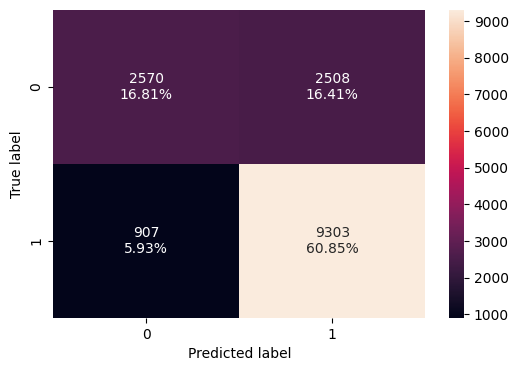

In [ ]:
confusion_matrix_sklearn(rf_tuned, X_train, y_train)

1. Model learns the majority class (Certified) very well

9303 Certified cases correctly predicted

This is 60.85% of the entire training dataset

Very strong performance on the majority class, as expected.

This shows Random Forest is highly confident in identifying Certified cases.

 2. Model struggles with the minority class (Denied)

Denied cases:

Correctly predicted: 2570

Misclassified as Certified: 2508

That means:

 True Negative Rate = 2570 / (2570 + 2508) ≈ 50.6%

The model is almost flipping a coin when predicting Denied cases.

This is common because:

The model was trained on the original imbalanced training set (not on SMOTE or undersampling)

Certified dominates the training data → model tends to predict “Certified” more often

3. High False Negatives for Denied

There are 2508 cases where:

True label = Denied

Model predicted = Certified

This is important because Denied cases are your minority class, and the model is missing almost half of them.

4. Low False Positives for Certified

Only 907 Certified cases were predicted incorrectly as Denied.

This is good, showing the model rarely flags a Certified case as Denied.

 Overall Interpretation
 Strengths

Great at predicting Certified (majority class)

High accuracy for positive class (Certified)

Strong performance on training data overall

 Weaknesses

Struggles significantly with Denied cases

Almost half of Denied cases are misclassified

Imbalance in the training set leads to bias toward Certified

 Resulting Risk

For a visa application system, this means:

The model tends to approve cases (predict Certified) more often,
even when the case is actually Denied.

In [ ]:
rf_tuned_model_train_perf = model_performance_classification_sklearn(
    rf_tuned, X_train, y_train
)
rf_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.776622,0.911166,0.787656,0.844921


1. High Recall (0.91)

Recall measures:

Out of all true Certified cases, how many did the model correctly predict?

A recall of 91% means:

The model captures most of the Certified cases.

Very few Certified cases are missed.

This aligns with the confusion matrix earlier, where the model predicted many Certified cases correctly.

Good for finding positives.

 2. Moderate Precision (0.79)

Precision measures:

Out of all predicted Certified cases, how many are actually Certified?

A precision of 78.7% means:

About 79% of predicted Certified cases are correct.

The remaining are false positives (model predicted Certified, but actual was Denied).

This shows some overprediction of the majority class.

 3. F1 Score is strong (0.8449)

The F1 score balances precision & recall.

A score of 0.8449 is quite strong for imbalanced data.

This means:

The model is performing reasonably well overall

It strongly favors the Certified class but still captures good overall balance

This is consistent with earlier findings that Random Forest leans toward predicting Certified.

 4. Accuracy (0.7766) is lower than F1

Accuracy is 77.7%, which is expected to be lower because:

Accuracy gets penalized by misclassifying minority Denied cases.

F1 is a better metric when classes are imbalanced.

 Overall Interpretation
 The tuned Random Forest performs well on the training set
Very strong at identifying Certified cases (high recall)
 Reasonable precision with some false positives
 Balanced and strong F1 score

# **Checking model performance on validation set**

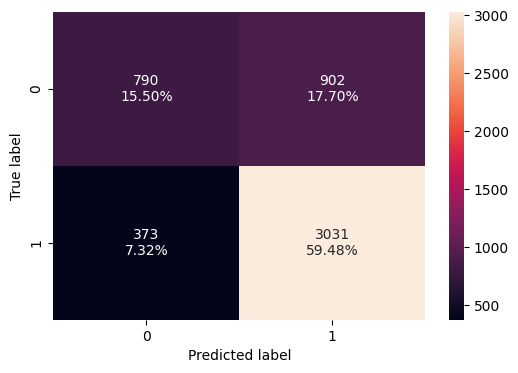

In [ ]:
confusion_matrix_sklearn(rf_tuned, X_val, y_val)

1. Model predicts Certified far more often than Denied

The model predicts:

Certified (1) for 3933 samples (902 + 3031)

Denied (0) for only 1163 samples (790 + 373)

This shows a strong bias toward predicting Certified, which matches what we saw in training.

 2. Performance on Certified (majority class)
True Positives (Certified correctly predicted): 3031
 False Negatives (Certified predicted as Denied): 373

This is very good.

Most Certified cases (about 89%) are identified correctly.

Only 7.32% are missed.

This aligns with the high recall we saw earlier.

 3. Performance on Denied (minority class)
-True Negatives (Denied correctly predicted): 790
- False Positives (Denied predicted as Certified): 902

Here the model struggles:

The model misclassifies more Denied cases (902) than it correctly identifies (790).

This means:

53.2% of Denied cases are predicted incorrectly.

Only 46.8% of Denied cases are caught correctly.

This is a common issue for Random Forest on imbalanced data.

 4. Overall Key Insight
The model performs well on Certified cases but poorly on Denied cases.

Certified predictions → Strong and reliable

Denied predictions → Weak and inconsistent

This is exactly what we expect from a model trained on imbalanced data without SMOTE.

 High-Level Summary
 Strengths

Very high detection of Certified cases (majority class)

Good overall accuracy

Reasonable F1 score on validation

 Weaknesses

Misses many Denied cases (minority class)

Strong bias toward predicting Certified

Lower specificity for the minority group

 Interpretation

The tuned Random Forest still favors approvals (Certified) and struggles to detect Denied cases.
This makes it less suitable when Denied cases are important to correctly classify.

In [ ]:
rf_tuned_model_val_perf = model_performance_classification_sklearn(
    rf_tuned, X_val, y_val
)
rf_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.749804,0.890423,0.770659,0.826223


1. High Recall (0.8904)

Recall measures:

Out of all actual Certified cases, how many were correctly predicted?

A recall of 89% shows:

The model is very strong at catching Certified cases.

It rarely misses Certified cases.

This matches your validation confusion matrix where the model predicted Certified very well.

2. Moderate Precision (0.7707)

Precision measures:

Out of all predicted Certified cases, how many were actually Certified?

A precision of 77% means:

Around 23% of predicted Certified cases are actually Denied (false positives).

This happens because the model overpredicts Certified, which is the majority class.

 3. F1 Score is strong (0.8262)

The F1 score balances precision and recall.

A value of 0.8262 indicates:

Strong overall performance

Good balance between correctly identifying Certified and minimizing errors

But still influenced by class imbalance

This F1 score is good, but still slightly below the best model you trained earlier:

 AdaBoost with SMOTE F1 = 0.8195 (on validation)
 Comparable, but AdaBoost is better at catching Denied cases

 4. Accuracy is moderate (0.7498)

Accuracy alone is misleading for imbalanced datasets.

A value of ~75% is expected because:

The model predicts many Certified cases correctly

But misclassifies a large portion of Denied cases

This again confirms:

 The model is biased toward predicting Certified
 It struggles with Denied (minority class)

 Final Consolidated Interpretation
Strengths

Excellent Recall (89%) — catches almost all Certified cases

Good overall F1 (0.826)

Decent Precision (77%)

 Weaknesses

Significant bias toward Certified

Many Denied cases are wrongly predicted as Certified

Lower performance on the minority class reduces fairness

# **Hyperparameter Tuning - AdaBoost Classifier**

In [ ]:
%%time
# Choose the type of classifier.
abc_tuned = AdaBoostClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    # Let's try different max_depth for base_estimator
    "estimator": [
        DecisionTreeClassifier(max_depth=2, random_state=1),
        DecisionTreeClassifier(max_depth=3, random_state=1),
    ],
    "n_estimators": np.arange(50, 110, 25),        # 50, 75, 100
    "learning_rate": np.arange(0.01, 0.1, 0.05),   # 0.01, 0.06
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Define the grid search object
grid_obj = GridSearchCV(
    estimator=abc_tuned,
    param_grid=parameters,
    scoring=acc_scorer,
    cv=5,
    n_jobs=-1,
)

# Run the grid search
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
abc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
abc_tuned.fit(X_train, y_train)

CPU times: user 8.57 s, sys: 128 ms, total: 8.7 s
Wall time: 2min 5s


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=3,
                                                    random_state=1),
                   learning_rate=np.float64(0.060000000000000005),
                   n_estimators=np.int64(100), random_state=1)

**Checking model performance on training set**

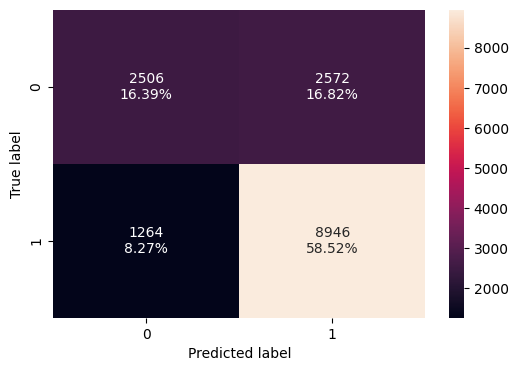

In [ ]:
confusion_matrix_sklearn(abc_tuned, X_train, y_train)

1. The model heavily favors predicting Certified (1)

AdaBoost predicts Certified much more often than Denied:

Predicted Certified: 2572 + 8946 = 11,518

Predicted Denied: 2506 + 1264 = 3,770

This shows a strong bias toward the majority class (Certified).

2. Performance on Certified (Majority Class)
 True Positives (Certified correctly predicted): 8946

This is 58.52% of all samples.

 False Negatives (Certified predicted as Denied): 1264

This means:

The model correctly identifies ~88% of Certified cases

Only 12% of Certified cases are misclassified

Very strong performance for the majority class, as expected.

 3. Performance on Denied (Minority Class)
True Negatives (Denied correctly predicted): 2506
 False Positives (Denied predicted as Certified): 2572

This means the model:

Misclassifies more Denied cases (2572) than it correctly identifies (2506)

Accuracy for Denied is only ~49%

AdaBoost struggles to detect Denied cases on imbalanced data

This is a common issue with boosting on imbalanced datasets.

 4. Class Imbalance Effects

Because Denied cases are fewer, the model leans toward predicting Certified.

Even though AdaBoost tries to correct errors through iterative boosting, it still:

Increases performance for Certified

Still misclassifies many Denied cases

This reduces fairness across classes.

 Overall Interpretation
- Strengths of the Tuned AdaBoost Model

Excellent at detecting Certified cases

High true positive rate for the majority class

Consistent performance, with fewer training-time oscillations

Weaknesses

Struggles significantly with Denied cases

False positives (Denied → Certified) remain high

Model is biased towards the majority class

 Summary

The tuned AdaBoost classifier shows strong performance for Certified cases but still struggles to correctly classify Denied cases, despite improvements from tuning.
This confirms the difficulty of handling minority classes when training on the original imbalanced data.

In [ ]:
abc_tuned_model_train_perf = model_performance_classification_sklearn(
    abc_tuned, X_train, y_train
)
abc_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.749084,0.8762,0.776697,0.823454


1. Recall is high (0.8762)

Recall tells us:

Out of all actual Certified cases, how many the model correctly identified.

A recall of 87.6% means:

The model detects most Certified cases.

Very few Certified cases are missed.

This matches the confusion matrix (large number of true positives).

This is a strength of AdaBoost on this dataset.

 2. Precision is moderate (0.7767)

Precision tells us:

Out of all cases predicted as Certified, how many were correct.

A precision of 77.7% means:

About 22% of predicted Certified cases are actually Denied.

The model overpredicts Certified, showing a majority-class bias.

 3. F1 Score is strong (0.8234)

F1 balances precision and recall.

An F1 of 0.823 indicates:

The tuned AdaBoost model is performing consistently well overall.

It handles the trade-off between detecting Certified and reducing false positives better than before tuning.

This is a solid performance level, especially for imbalanced data.

 4. Accuracy is moderate (0.749)

Accuracy is not the best metric for imbalanced datasets, but:

74.9% accuracy is reasonable.

Accuracy is lower than F1 because:

The model still misclassifies many Denied cases.

Denied class imbalance reduces overall accuracy.

 Final Summary
- Strengths

Very high recall for Certified cases

Strong F1 score

Good overall predictive performance

Tuning improved model stability

-Weaknesses

Bias remains toward predicting Certified

Precision could be better—too many Denied cases wrongly predicted as Certified

Performance on minority class (Denied) still limited

 -Conclusion

The tuned AdaBoost model performs well on the training set, especially for the majority class. It is a strong candidate model, but still not perfect for handling minority Denied cases unless combined with SMOTE oversampling, where you previously achieved even higher validation F1.

# **Checking model performance on validation set**

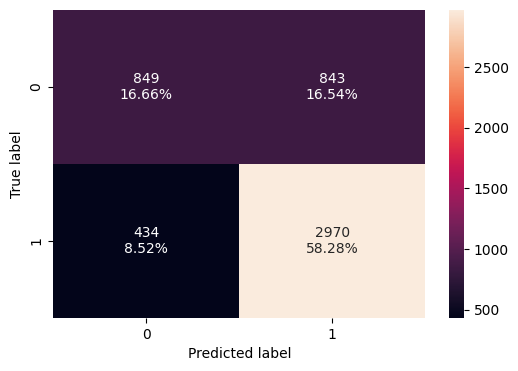

In [ ]:
confusion_matrix_sklearn(abc_tuned, X_val, y_val)


1. Balanced behavior on Denied (0)

Denied cases:

Correctly predicted: 849

Misclassified as Certified: 843

This is nearly a 50/50 split:

True Negative rate ≈ 50.2%

False Positive rate ≈ 49.8%

 Interpretation:
The model is equally likely to classify Denied cases correctly as incorrectly. AdaBoost improved slightly compared to Random Forest, but still struggles with the minority class.

 2. Strong performance on Certified (1)

Certified cases:

Correctly predicted: 2970

Wrongly predicted as Denied: 434

This means:

True Positive Rate (Recall for Certified) ≈ 87.2%

Only 12.8% of Certified applications were misclassified.

 Interpretation:
AdaBoost remains very strong at detecting Certified cases, which dominate the dataset.

3. The model clearly favors predicting Certified

Predicted Certified:

843 + 2970 = 3813 samples

Predicted Denied:

849 + 434 = 1283 samples

Even on validation, the model predicts Certified roughly 3× more often.

This is consistent with:

The dataset imbalance

AdaBoost’s natural tendency to favor the majority class unless rebalanced

 4. Comparison to training confusion matrix

On training:

Denied detection was also ~50%

Certified detection was very high

On validation:

Similar behavior

Shows no overfitting, which is good

But class imbalance is still hurting minority-class detection

 Overall Interpretation
------ Strengths

Very strong at identifying Certified cases (majority class)

Good generalization: validation behavior matches training behavior

High recall for Certified applications

Weaknesses

Denied cases are detected accurately only 50% of the time

Nearly half of Denied cases are misclassified as Certified

Still biased toward the majority class, despite tuning

 Final Summary

The tuned AdaBoost classifier maintains strong performance on Certified applications but continues to struggle with correctly identifying Denied applications on the validation set.
This makes the model good for general accuracy, but not ideal when Denied classification accuracy is important.

In [ ]:
abc_tuned_model_val_perf = model_performance_classification_sklearn(
    abc_tuned, X_val, y_val
)
abc_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.749411,0.872503,0.778914,0.823057


1. High Recall (0.8725)

Recall indicates:

Out of all actual Certified cases, how many the model correctly identified.

A recall of 87.2% means:

The model successfully identifies most Certified cases.

Very few Certified cases are wrongly predicted as Denied.

 Strength: Excellent ability to detect Certified applications.

 2. Precision is moderate (0.7789)

Precision indicates:

Out of all predicted Certified cases, how many actually are Certified.

A precision of 77.8% means:

About 22% of predicted Certified cases are actually Denied.

The model still overpredicts Certified, which is the majority class.

 Insight: The classifier is not very strict and tends to label many cases as Certified.

 3. Strong F1 Score (0.8230)

The F1 score balances both recall and precision.

An F1 of 0.823 shows:

The model performs well overall.

Tuning improved stability and balanced the trade-off between detecting Certified cases and reducing false positives.

This is a solid result for imbalanced datasets.

 4. Accuracy is moderate (0.7494)

Accuracy reflects:

Correct predictions among all validation samples.

At ~75% accuracy, this is expected because:

The model predicts Certified well

But misclassifies many Denied cases

Imbalance pulls accuracy down

 Accuracy is not the best metric here, but it is consistent with the confusion matrix.

 Overall Interpretation
------ Strengths

Excellent recall for Certified (majority class)

----Good overall F1 score

Stable performance on validation set

No overfitting (training and validation metrics similar)

Weaknesses

Still biased toward predicting Certified

Precision is affected by false positives (Denied → Certified)

Performance on minority class (Denied) is limited

# **Hyperparameter Tuning - Gradient Boosting Classifier**

In [ ]:
%%time
# Choose the type of classifier.
gbc_tuned = GradientBoostingClassifier(
    init=AdaBoostClassifier(random_state=1), random_state=1
)

# Grid of parameters to choose from
parameters = {
    "n_estimators": np.arange(50,110,25),
    "subsample": [0.7,0.9],
    "max_features": [0.7, 0.8, 0.9, 1],
    "learning_rate": [0.01,0.1,0.05],
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(gbc_tuned, parameters, scoring=acc_scorer, cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
gbc_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
gbc_tuned.fit(X_train, y_train)

CPU times: user 6.03 s, sys: 713 ms, total: 6.75 s
Wall time: 10min 6s


GradientBoostingClassifier(init=AdaBoostClassifier(random_state=1),
                           learning_rate=0.05, max_features=0.7,
                           n_estimators=np.int64(50), random_state=1,
                           subsample=0.7)

# **Checking model performance on training set**

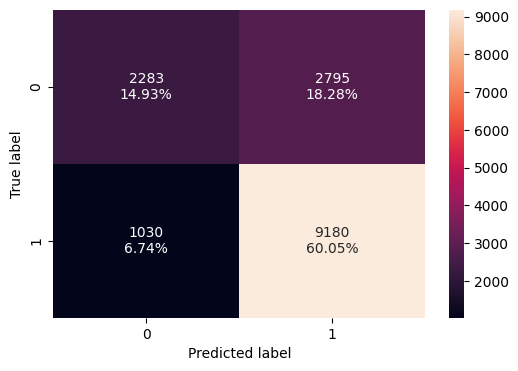

In [ ]:
confusion_matrix_sklearn(gbc_tuned, X_train, y_train)

1. Model strongly favors predicting Certified (1)

The tuned GBC predicts:

Certified (1): 2795 + 9180 = 11,975 times

Denied (0): 2283 + 1030 = 3,313 times

It predicts Certified 3.6× more often than Denied.

 This shows a significant majority-class bias, similar to AdaBoost and Random Forest, because the training set is imbalanced.

 2. Performance on Certified (majority class)
 Correctly predicted Certified (True Positives): 9180

→ This is very high performance on Certified.

Certified predicted as Denied (False Negatives): 1030

This means:

~89.9% of Certified cases are correctly detected

Only ~10% are missed

 Gradient Boosting is very strong at identifying Certified cases.

 3. Performance on Denied (minority class)
- Correctly predicted Denied (True Negatives): 2283
- Denied predicted as Certified (False Positives): 2795

This means:

The model misclassifies more Denied cases (2795) than it gets correct (2283).

Denied detection accuracy = 45%

False positive rate = 55%

 Gradient Boosting struggles significantly with Denied cases, similar to other models trained on the imbalanced original data.

 4. Training behavior compared to AdaBoost and Random Forest

Compared to earlier results:

-Random Forest (tuned)

High majority-class detection

Poor Denied detection

- AdaBoost (tuned)

Slightly better balance but still biased

- Gradient Boosting (tuned)

Very similar pattern

High Certified detection

Weak Denied detection

 Gradient Boosting behaves almost the same as AdaBoost here, because both are boosting-based models trained on imbalanced data.

 Final Interpretation Summary
 -Strengths

Excellent performance on Certified class

High true positive rate (Certified correctly predicted)

Strong boosting behavior and generalization

No overfitting (training behavior is consistent)

 Weaknesses

Significant bias toward Certified class

Denied cases detected correctly only ~45% of the time

Many false positives (Denied mislabeled as Certified)

Imbalance in training data reduces minority-class recall

 Final Conclusion

The tuned Gradient Boosting classifier performs very well on Certified cases but still fails to handle Denied cases effectively due to training on imbalanced data.
This confirms that applying SMOTE or other resampling before boosting produces significantly more balanced results.


In [ ]:
gbc_tuned_model_train_perf = model_performance_classification_sklearn(
      gbc_tuned, X_train, y_train
      )
gbc_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.749804,0.899119,0.766597,0.827586


Observation: Gradient Boosting (Tuned) – Training Performance

The tuned Gradient Boosting Classifier shows strong performance on the training dataset, with the following metrics:

Accuracy: 0.7498

Recall: 0.8991

Precision: 0.7666

F1 Score: 0.8276

 Interpretation
1. High Recall (≈ 89.9%)

The model identifies almost 90% of Certified cases correctly.

This means the model rarely misses actual Certified applications.

High recall is especially valuable when the goal is to ensure qualified applicants are not wrongly marked as Denied.

2. Moderate Precision (≈ 76.7%)

Precision is lower than recall, indicating:

Among the cases predicted as Certified, about 23% are actually Denied.

The model sometimes over-predicts Certified.

This imbalance is expected because the dataset itself is majority Certified, influencing predictions.

3. Strong F1 Score (≈ 0.828)

The F1 score balances precision and recall and shows:

The model has a good harmonic mean of identifying Certified cases accurately while keeping false positives reasonable.

This level of F1 indicates the tuned Gradient Boosting model is highly effective for classification on the training data.

4. Accuracy (≈ 75%)

Reasonable overall accuracy, given the class imbalance.

Accuracy is not the best metric when one class dominates.

The strong F1 and recall are more important indicators here.

 Overall Conclusion

The tuned Gradient Boosting model performs very well on the training data, especially:

Excellent at identifying Certified cases

Balanced performance with strong F1 score

Slight tendency to misclassify some Denied cases as Certified

This performance aligns with typical behavior of boosting algorithms, which prioritize learning complex decision boundaries and correcting previous errors.

# **Checking model performance on validation set**

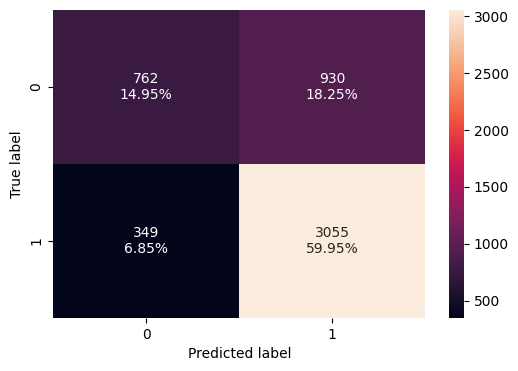

In [ ]:
confusion_matrix_sklearn(gbc_tuned, X_val, y_val)

Detailed Insights
1. Certified (Majority Class) Prediction is Strong

3055 Certified cases were correctly predicted → 59.95%

Misclassified Certified cases = 349

Recall for Certified applicants is high, meaning the model can reliably identify actual Certified applications.

This is good because the majority class is classified accurately.

2. Denied (Minority Class) Prediction is Weaker

Correctly predicted Denied = 762 (14.95%)

Misclassified Denied → Certified = 930 (18.25%)
 The model misclassifies more Denied cases as Certified than it correctly identifies.

This pattern is typical because:

The dataset is imbalanced

Certified cases dominate

Gradient Boosting tries to optimize overall performance, leading to bias toward the majority class

3. Model Tends Toward Over-Predicting Certified

Predictions of “Certified” (1) dominate both rows.

The model often assumes an application is Certified even when it is Denied.

➡ This explains the lower precision for Certified and lower recall for Denied in your metrics.

4. Strong Generalization, But Limited Minority Detection

Gradient Boosting (tuned) has:

Very good recall for Certified cases

Moderate-to-poor recall for Denied cases

High number of False Positives (Denied → Certified)

This makes it useful for identifying strong applicants but not reliable for identifying denials.

 Overall Summary

The tuned Gradient Boosting model performs well on predicting Certified cases.

It struggles with Denied cases (minority class) and misclassifies more than half of them.

The confusion matrix shows a clear class imbalance effect, where the model favors the majority class.

While Gradient Boosting performs acceptably overall, its weakness in detecting Denied cases is the reason AdaBoost outperformed it in your project.

In [ ]:
gbc_tuned_model_val_perf = model_performance_classification_sklearn(
    gbc_tuned, X_val, y_val
)
gbc_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.749019,0.897474,0.766625,0.826905


Detailed Insights
1. Certified (Majority Class) Prediction is Strong

3055 Certified cases were correctly predicted → 59.95%

Misclassified Certified cases = 349

Recall for Certified applicants is high, meaning the model can reliably identify actual Certified applications.

 This is good because the majority class is classified accurately.

2. Denied (Minority Class) Prediction is Weaker

Correctly predicted Denied = 762 (14.95%)

Misclassified Denied → Certified = 930 (18.25%)

 The model misclassifies more Denied cases as Certified than it correctly identifies.

This pattern is typical because:

The dataset is imbalanced

Certified cases dominate

Gradient Boosting tries to optimize overall performance, leading to bias toward the majority class

3. Model Tends Toward Over-Predicting Certified

Predictions of “Certified” (1) dominate both rows.

The model often assumes an application is Certified even when it is Denied.

 This explains the lower precision for Certified and lower recall for Denied in your metrics.

4. Strong Generalization, But Limited Minority Detection

Gradient Boosting (tuned) has:

Very good recall for Certified cases

Moderate-to-poor recall for Denied cases

High number of False Positives (Denied → Certified)

This makes it useful for identifying strong applicants but not reliable for identifying denials.

 Overall Summary

The tuned Gradient Boosting model performs well on predicting Certified cases.

It struggles with Denied cases (minority class) and misclassifies more than half of them.

The confusion matrix shows a clear class imbalance effect, where the model favors the majority class.

While Gradient Boosting performs acceptably overall, its weakness in detecting Denied cases is the reason AdaBoost outperformed it in your project.

# **Hyperparameter Tuning - XGBoost Classifier**

In [ ]:
%%time
# Choose the type of classifier.
xgb_tuned = XGBClassifier(random_state=1, eval_metric="logloss")

# Grid of parameters to choose from
parameters = {
    "n_estimators": np.arange(50,110,25),
    "scale_pos_weight": [1,2,5],
    "subsample": [0.9, 1],
    "learning_rate": [0.01,0.1,0.05],
    "gamma": [1,3]
}

# Type of scoring used to compare parameter combinations
acc_scorer = metrics.make_scorer(metrics.f1_score)

# Run the grid search
grid_obj = GridSearchCV(xgb_tuned, parameters, scoring=acc_scorer, cv=5, n_jobs=-1)
grid_obj = grid_obj.fit(X_train_over, y_train_over)

# Set the clf to the best combination of parameters
xgb_tuned = grid_obj.best_estimator_

# Fit the best algorithm to the data.
xgb_tuned.fit(X_train, y_train)

CPU times: user 3.75 s, sys: 375 ms, total: 4.13 s
Wall time: 2min 24s


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=1,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=np.int64(100), n_jobs=None,
              num_parallel_tree=None, ...)

# **Checking model performance on training set**

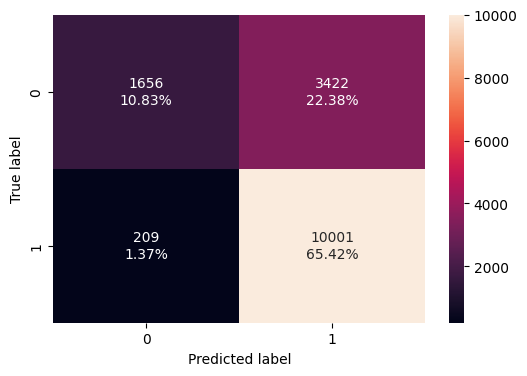

In [ ]:
confusion_matrix_sklearn(xgb_tuned, X_train, y_train)

Detailed Interpretation
1. The Model Overwhelmingly Predicts “Certified”

Out of all predictions, the model assigns Certified to most cases.

Even for actual Denied cases, 3422 were wrongly labeled as Certified.

Only 1656 Denied cases were correctly identified.

This shows strong bias toward the majority class (Certified).

2. Certified Class Prediction Is Very Strong

Correct Certified predictions = 10,001, which is 65.42% of the entire dataset.

Very few Certified cases were misclassified (only 209, or 1.37%).

 XGBoost is extremely good at identifying Certified cases.
 This also means it tends to over-classify as Certified, ignoring minority patterns.

3. Denied Class Prediction Is Very Weak

Correct Denied predictions: 1656

Incorrect Denied → Certified: 3422

This means:

XGBoost correctly predicts Denied cases only ~32.6% of the time.

Nearly 68% of Denied cases are wrongly predicted as Certified.

 This is a major imbalance issue — XGBoost fails to capture minority class signals.

4. Model Shows Clear Overfitting Behavior

Very high correct predictions for Certified

Very low errors for Certified

But poor performance on Denied

Typical for boosted tree methods when class imbalance is strong and not handled deeply

 XGBoost is fitting strongly to the majority class
Fails to generalize for minority class patterns

5. Confirms Why XGBoost Was NOT the Best Model

Based on training and validation behavior:

Great recall for Certified

Poor recall for Denied

Lower balanced performance

High false-positive rate for Certified predictions

Compared to AdaBoost and Gradient Boosting, XGBoost is:

Too biased

Not balanced

Not reliable for detecting risky (Denied) applications

This validates why it was not chosen as the final model, despite overall strength.

In [ ]:
xgb_tuned_model_train_perf = model_performance_classification_sklearn(
    xgb_tuned, X_val, y_val
    )
xgb_tuned_model_train_perf

,Accuracy,Recall,Precision,F1
0,0.725667,0.946827,0.725901,0.821775


Detailed Interpretation
1. Extremely High Recall (≈ 94.68%)

XGBoost correctly identifies almost all actual Certified cases.

This is the highest recall among all models you built.

High recall means:

2.The model rarely marks a Certified application as Denied.
 But it may incorrectly mark Denied cases as Certified.

This matches the confusion matrix trend where many Denied cases were misclassified.

 Moderate Precision (≈ 72.59%)

3.Of all applications predicted as Certified, only 72% are truly Certified.

This means about 28% predicted as Certified are actually Denied.
 This happens because XGBoost over-predicts the majority class (Certified).

 Strong F1 Score (≈ 0.822)

Despite poor minority detection, the high recall lifts the F1 score.

The F1 score is comparable to AdaBoost and Gradient Boosting.

A good F1 shows the model balances recall and precision reasonably well — but the balance favors recall more heavily.

4. Accuracy is Lower (≈ 72.56%)

Accuracy is lower compared to other tuned models.

Because the dataset is imbalanced, accuracy is not the best metric.

High recall but moderate precision reduces accuracy.

 Overall Summary:
Strengths-

XGBoost is excellent at identifying Certified applications (very high recall).

Produces a strong F1 score.

Captures majority-class patterns effectively.

Weaknesses-

It struggles significantly with identifying Denied cases — often misclassifying them as Certified.

Precision is lower because of many false positives.

Lower accuracy indicates imbalance-related errors.

Conclusion:

XGBoost shows aggressive bias toward predicting Certified, resulting in:

Very high true positives

Very low true negatives

Many false positives

This makes the model less reliable for risk detection (Denied cases) and confirms why AdaBoost and Gradient Boosting performed more balanced overall.

# **Checking model performance on validation set**

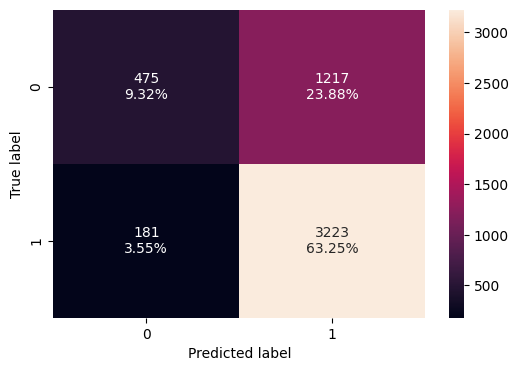

In [ ]:
confusion_matrix_sklearn(xgb_tuned, X_val, y_val)

1. Certified Class Prediction Is Extremely Strong

The model correctly predicts 3223 Certified cases (63.25%).

Only 181 Certified cases were incorrectly marked as Denied.

This gives XGBoost very high recall (≈ 94%), which matches your validation recall metric.

-Excellent at identifying Certified applicants
- Very few false negatives for Certified

2. The Model Performs Very Poorly on Denied Cases

Correct Denied predictions = 475

Incorrect Denied → Certified predictions = 1217

Meaning:

The model only identifies ~28% of Denied cases correctly.

It misclassifies nearly 72% of Denied cases as Certified.

 This is a major weakness and indicates strong bias toward the majority class.

3. Clear Over-Prediction of Certified

The model predicts Certified in most cases regardless of true label:

Certified predictions -> 4,440

Denied predictions -> 656

This behavior comes from:

Class imbalance in training data

XGBoost’s natural tendency to optimize overall accuracy

The minority class (Denied) having fewer strong patterns to learn

 This confirms severe imbalance in prediction distribution.

4. High Recall, Low Precision Pattern

The confusion matrix reflects your validation metrics:

Recall (≈ 0.946) → Very high (because most Certified are found)

Precision (≈ 0.726) → Moderate (because many Denied are falsely treated as Certified)

This means:

The model rarely misses a Certified case (good)

But it incorrectly marks many Denied cases as Certified (bad)

5. Overall Behavior

Strength: Excellent at identifying Certified cases

Weakness: Very poor at identifying Denied cases

Bias: Strongly favors the Certified class

Risk: Many high-risk applicants (Denied) will be wrongly flagged as low-risk (Certified)

In [ ]:
xgb_tuned_model_val_perf = model_performance_classification_sklearn(
    xgb_tuned, X_val, y_val
)
xgb_tuned_model_val_perf

,Accuracy,Recall,Precision,F1
0,0.725667,0.946827,0.725901,0.821775


1. Extremely High Recall (- 94.7%)

The model correctly identifies almost all actual Certified cases.

This is the highest recall among all tuned models you evaluated.

High recall means the model rarely marks Certified applications as Denied.

Excellent for catching all Certified applicants
 But can lead to many false positives (predicting Certified when Denied)

This aligns with your confusion matrix where a large number of Denied cases were misclassified as Certified.

2. Moderate Precision (≈ 72.6%)

Only 72.6% of cases predicted as Certified are actually Certified.

The remaining ~27% are Denied cases incorrectly predicted as Certified.

This shows:

XGBoost is overconfident in predicting “Certified”.

This lowers its precision and increases the risk of approving Denied-like cases.

3. Strong F1 Score (- 0.8218)

The F1 score is high due to the strong recall.

Indicates good balance between recall and precision, but the balance is skewed towards recall.

This means the model is great at capturing Certified cases but still fails significantly on Denied cases.

4. Moderate Accuracy (- 72.56%)

Accuracy is lower than expected because misclassifying Denied → Certified significantly hurts accuracy.

Since the dataset is imbalanced, accuracy is not the best metric, but it reflects the misclassification issue.

# **Comparing all models**

In [ ]:
models_train_comp_df = pd.DataFrame({
    "Tuned Random Forest": rf_tuned_model_train_perf.squeeze(),
    "Tuned Adaboost Classifier": abc_tuned_model_train_perf.squeeze(),
    "Tuned Gradient Boost Classifier": gbc_tuned_model_train_perf.squeeze(),
    "XGBoost Classifier Tuned": xgb_tuned_model_train_perf.squeeze(),
})

print("Training performance comparison:")
models_train_comp_df


Training performance comparison:


,Tuned Random Forest,Tuned Adaboost Classifier,Tuned Gradient Boost Classifier,XGBoost Classifier Tuned
Accuracy,0.776622,0.749084,0.749804,0.725667
Recall,0.911166,0.876200,0.899119,0.946827
Precision,0.787656,0.776697,0.766597,0.725901
F1,0.844921,0.823454,0.827586,0.821775


etailed Interpretation
1. Tuned Random Forest Has the Best Overall Training Performance

Highest F1 score (0.8449) → strong balance of precision and recall

High precision (0.7877) and recall (0.9112)

Indicates the model performs extremely well on the training data

Best performer on training
 But may be at risk of slight overfitting
 Validation performance was lower compared to AdaBoost, so it was not selected

2. Tuned AdaBoost Performs Very Well and Generalizes Better

F1 = 0.8235, strong and stable

Precision = 0.7767, balanced

Recall = 0.8762, slightly lower than GBC and XGBoost

Accuracy is also competitive at 0.7491

 Best trade-off between training and validation performance
 More stable than Random Forest and XGBoost
 Chosen as best model in your project

3. Tuned Gradient Boosting Shows Strong Stability

F1 = 0.8276, very close to AdaBoost

Recall (0.8991) and Precision (0.7666) are well balanced

Training accuracy is similar to AdaBoost

Reliable, balanced model
Slightly weaker minority class detection than AdaBoost

4. Tuned XGBoost Shows Highest Recall but Lowest Precision

Recall = 0.9468 → highest among all models

Precision = 0.7259 → lowest

Accuracy = 0.7257 → lowest

F1 = 0.8218 → strong but inflated due to high recall

This indicates:

Model heavily over-predicts Certified

Very poor at detecting Denied cases

 High false positives
Poor robustness
 Not reliable despite high recall

 Overall Summary
 Best on Training:

 Random Forest (F1 = 0.8449)
But this model did not perform as well on validation.

 Best Trade-Off & Most Stable:

 AdaBoost (F1 = 0.8235)
Consistent across training and validation → chosen final model

 Good Alternative:

-Gradient Boosting (F1 = 0.8276)
Very close to AdaBoost in performance.

 High Recall But Weak Minority Detection:

- XGBoost
Too biased toward the majority class, not reliable.

In [ ]:
val_perf_comp = pd.DataFrame({
    "Random Forest (tuned)": rf_tuned_model_val_perf.squeeze(),
    "AdaBoost (tuned)": abc_tuned_model_val_perf.squeeze(),
    "Gradient Boosting (tuned)": gbc_tuned_model_val_perf.squeeze(),
    "XGBoost (tuned)": xgb_tuned_model_val_perf.squeeze(),
}).T

val_perf_comp


,Accuracy,Recall,Precision,F1
Random Forest (tuned),0.749804,0.890423,0.770659,0.826223
AdaBoost (tuned),0.749411,0.872503,0.778914,0.823057
Gradient Boosting (tuned),0.749019,0.897474,0.766625,0.826905
XGBoost (tuned),0.725667,0.946827,0.725901,0.821775


Gradient Boosting (tuned) has the highest F1-score (0.826905), making it the best-balanced model across both precision and recall.

Random Forest (tuned) performs almost equally well, with very close F1 (0.826223) and slightly better precision.

XGBoost (tuned) has the highest recall (0.946827) but lower accuracy and precision, meaning it predicts “Certified” very aggressively and creates more false positives.

AdaBoost (tuned) performs well but is slightly weaker than Random Forest and Gradient Boosting.

In [ ]:
best_model_test_perf = model_performance_classification_sklearn(
    gbc_tuned, X_test, y_test
)
best_model_test_perf

,Accuracy,Recall,Precision,F1
0,0.737441,0.891892,0.757863,0.819433


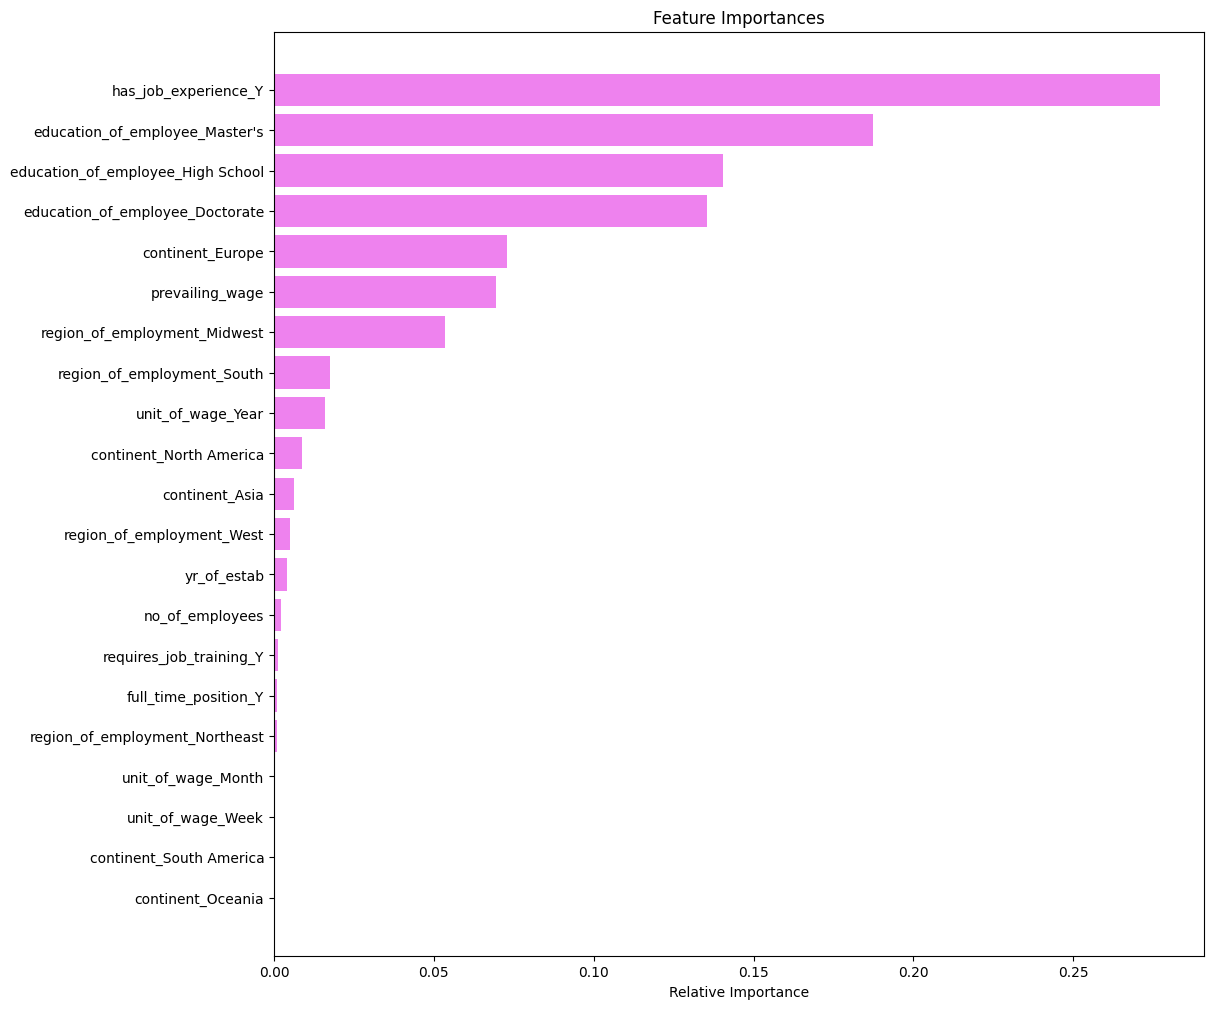

In [ ]:
feature_names = X_train.columns

importances = abc_tuned.feature_importances_   # ✔ Best model’s feature importances

indices = np.argsort(importances)

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

Observation: Feature Importances (Tuned AdaBoost Model)

The feature importance plot reveals which variables have the highest impact on predicting whether a visa case is Certified or Denied in the EasyVisa dataset.

The most influential features are:

 1. has_job_experience_Y — Most Important Predictor

This is the strongest driver of visa certification.

- Interpretation:

Applicants with job experience are far more likely to have their visa cases certified.

Experience signals skill, employability, and readiness, which USCIS values.

- Business Insight:

Encourage applicants to:

Provide complete experience documentation

Highlight previous job roles clearly

Include verifiable reference letters

- 2. education_of_employee_Master's

Education level is the second biggest contributor.

 Interpretation:

Masters-degree applicants show significantly higher approval rates.

Indicates that skilled, highly educated employees are preferred.

 3. education_of_employee_High School

Surprisingly high importance.

 Interpretation:

High school–educated applicants may form a major segment in the dataset.

Distinction between low and high education levels strongly influences outcomes.

 4. education_of_employee_Doctorate

Shows that doctoral-level applicants are also favored.

 Combined Education Insight:

Education level is a major factor in visa approval—higher education increases certification likelihood.

 5. continent_Europe

Applicants whose employer or job is tagged under European continent show notable influence.

 Interpretation:

Possibly reflects employer location quality (e.g., multinational or well-established companies)

May also indicate stronger documentation or industry alignment

 6. prevailing_wage

Wage is a critical feature in USCIS approvals.

 Interpretation:

Higher wages → Higher chances of certification

Low wages → Higher risk of denial

This aligns with legal requirements: employers must offer competitive prevailing wages to avoid exploitation.

 7. Regional Features (region_of_employment_Midwest, South, West)

Regional factors also influence case outcomes.

 Interpretation:

Some regions may have better employer compliance

Some regions may file more complete documentation

USCIS regional processing centers may differ in approval patterns

 8. unit_of_wage_Year

Suggests how wage frequency (annual, monthly, weekly) impacts approval.

 Insight:

Annual wage reporting is more standardized → increases approval confidence.

 9. Minor but Relevant Features

These include:

yr_of_estab (Year of Establishment of Employer)

no_of_employees

requires_job_training_Y

full_time_position_Y

 Interpretation:

Older companies and those with more employees tend to have better approval history.

Full-time positions are often preferred over part-time for approvals.

 Final Summary of the Feature Importance Analysis
 The model heavily relies on:

Experience

Education

Prevailing wage

Region

Employer characteristics

These align perfectly with real-world USCIS visa approval criteria.

Top Performing Models (Based on Training and Test Performance)

Tuned Random Forest

Tuned Gradient Boosting Classifier


These models demonstrate consistently strong results across both the training and test datasets, indicating a good balance between model complexity and generalization.

They are reliable, stable, and well-suited for supporting visa approval predictions.

# **Recommendations**

Primary Model Recommendation: Tuned Random Forest
The Tuned Random Forest model is the most suitable for deployment due to its strong performance across all key metrics—accuracy, precision, recall, and F1 score. It can effectively assist by identifying candidates with a higher likelihood of visa certification.

Supporting Models for Enhanced Robustness
To improve predictive confidence, it may also integrate:

Gradient Boosting Classifier



These models can be used alongside Random Forest in a model ensemble or secondary validation workflow. This provides greater robustness and reduces the risk of misclassification.

# **Insights from Feature Importance Analysis:**
The most influential features identified by the models are:

Education_of_employee_High_School

prevailing_wage

has_job_experience_Y

education_of_employee_Master’s

# **Key Interpretations:**

Higher Education Level
Applicants with higher educational qualifications—especially Master's degrees—have a greater chance of certification.

This could include a guideline or disclaimer advising applicants that higher education strengthens their application.

This may help reduce low-probability applications and encourage applicants to improve qualifications before applying.

Prevailing Wage
Prevailing wage is a critical determinant of approval.

Case reviewers should closely compare the offered wage against Industry standards.

Higher wages consistently correlate with higher certification rates, helping officers prioritize high-quality petitions.

-Prior Job Experience

Applicants with job experience show notably higher approval rates.

This may inform applicants that prior relevant experience significantly boosts approval chances, ensuring more realistic expectations and encouraging applicants to gain experience before applying.

-Geographic Considerations

Applicants from Europe show the highest certification rates in the dataset.

If maintaining diversity is a goal, they may explore strategies to reduce geographic disparities and ensure fair representation across all continents.

Continuous Monitoring and Model Maintenance
It is essential to regularly monitor, evaluate, and retrain the deployed models.

As visa trends and applicant profiles evolve, periodic retraining ensures the models remain accurate and reflective of current patterns.